## === DATA PREPROCESS v11.5 ===

In [ ]:
import torch
import torch_geometric
from torch_geometric.data import Data, Dataset
from torch_geometric.transforms import RandomLinkSplit
import numpy as np
import pickle
import random
from collections import defaultdict
import pandas as pd
import gzip

def get_ppi_list(ppi_pth):
    """Reads the PPI file and adds the interactions to a list of tuples"""
    ppi = []
    with open(ppi_pth, "r") as f:  
        ppi += [(x.split(",")[0], x.split(",")[1].strip('\n')) if ',' in x else
                (x.split("\t")[0], x.split("\t")[1].strip('\n')) for x in f] 
    return ppi

def get_STRING_id_dict(aliases_path):
    """Returns dictionary mapping protein aliases"""
    aliases = pd.read_table(aliases_path, delimiter="\t", skiprows=[0])
    return dict(zip(aliases.iloc[:, 1], aliases.iloc[:, 0]))

def protein_annot_string_to_dict(annot_filename, aliases_path, unique=True):
    """Creates dictionary of protein annotations: ProtId -> [GO1, GO2 ...]"""
    string_id_dict = get_STRING_id_dict(aliases_path)
    protein_go_anno = defaultdict(list)
    
    with gzip.open(annot_filename, 'rt', encoding='utf8', errors="ignore") as f:
        for line in f:
            if line.startswith('!'): # Skip header
                continue
            line = line.strip().split('\t')
            protein_id = line[1]
            go_term = line[4]
            if line[6] == 'IEA' or line[6] == 'ND': # Ignore predicted or no data annotations
                continue
            if protein_id not in string_id_dict: # Not in StringDB
                continue
                
            string_id = string_id_dict[protein_id]
            
            if not unique:
                protein_go_anno[string_id].append(go_term)
            elif go_term not in protein_go_anno[string_id]:
                protein_go_anno[string_id].append(go_term)
    return protein_go_anno

def filter_interactions(ppi, protein_go_anno, go_id_dict_pth, go_name_space_dict_pth, go_filter, intr_set_size_filter, max_intr_size):
    """Filters interactions based on GO annotations"""
    with open(go_id_dict_pth, 'rb') as fp:
        go_id_dict = pickle.load(fp)
        
    with open(go_name_space_dict_pth, 'rb') as fp:
        go_name_space_dict = pickle.load(fp)
    
    filtered_ppi = []
    rejected_no_annot = 0
    rejected_filter = 0
    for (protA, protB) in ppi:
        
        for prot in [protA, protB]:
            protein_go_anno[prot] = [go for go in protein_go_anno[prot] if go in go_id_dict]

            if go_filter != "ALL":
                protein_go_anno[prot] = [go for go in protein_go_anno[prot] if go_filter in go_name_space_dict[go]]
        
        if len(protein_go_anno[protA]) > 0 and len(protein_go_anno[protB]) > 0:
            intr_set_size = (len(protein_go_anno[protA]) + len(protein_go_anno[protB]))
            if intr_set_size >= intr_set_size_filter[0] and intr_set_size <= intr_set_size_filter[1]:
                if max_intr_size == len(filtered_ppi):
                    return filtered_ppi, protein_go_anno
                filtered_ppi.append((protA, protB))
            else:
                rejected_filter += 1
        else:
            rejected_no_annot += 1
    
    print("Rejected interactions where at least one protein has no annotation:", rejected_no_annot)
    print(f"Rejected interactions where go_filter={go_filter} and intr_set_size_filter={intr_set_size_filter}:", rejected_filter)
    print("Number of interactions:", len(filtered_ppi))
    return filtered_ppi, protein_go_anno

def go_embeddings_to_dict(go_embed_pth):
    """Read the embeddings generated by Node2vec"""
    embeddings_dict = {}
    embeddings = open(go_embed_pth).read().splitlines()[1:]
    embeddings = [x.split(" ") for x in embeddings]

    for i in range(0, len(embeddings)):
        key = int(embeddings[i][0]) 
        embeddings_dict[key] = [float(x) for x in embeddings[i][1:]]
        
    return embeddings_dict

def create_protein_node_features(protein_ids, protein_go_anno, go_id_dict, go_emb_dict):
    """Creates node features for proteins by averaging their GO term embeddings"""
    node_features = {}
    embedding_dim = next(iter(go_emb_dict.values())).__len__()
    
    for protein_id in protein_ids:
        if protein_id in protein_go_anno and protein_go_anno[protein_id]:
            # Get GO terms for this protein
            go_terms = protein_go_anno[protein_id]
            # Convert GO terms to embedding indices
            go_indices = [go_id_dict[go] for go in go_terms if go in go_id_dict]
            
            if go_indices:
                # Get and average the embeddings
                embeddings = [go_emb_dict[idx] for idx in go_indices if idx in go_emb_dict]
                if embeddings:
                    node_features[protein_id] = np.mean(embeddings, axis=0)
                else:
                    # Fallback: zero vector
                    node_features[protein_id] = np.zeros(embedding_dim)
            else:
                # Fallback: zero vector
                node_features[protein_id] = np.zeros(embedding_dim)
        else:
            # Fallback: zero vector
            node_features[protein_id] = np.zeros(embedding_dim)
    
    return node_features

def prepare_gnn_data_custom_split(poz_path, neg_path, protein_go_anno_pth, go_id_dict_pth, go_embed_pth, 
                                aliases_path, go_name_space_dict_pth, go_filter="ALL", 
                                intr_set_size_filter=[0, 5000], max_intr_size=None, 
                                val_ratio=0.16, test_ratio=0.2):
    """Prepares graph data with custom train/val/test splits ensuring binary classification"""
    # Load PPIs
    ppi_poz = get_ppi_list(poz_path)
    ppi_neg = get_ppi_list(neg_path)
    
    # Load protein annotations
    protein_go_anno = protein_annot_string_to_dict(protein_go_anno_pth, aliases_path)
    
    # Filter interactions
    ppi_poz, protein_go_anno = filter_interactions(
        ppi_poz, protein_go_anno, go_id_dict_pth, go_name_space_dict_pth, 
        go_filter, intr_set_size_filter, max_intr_size
    )
    ppi_neg, protein_go_anno = filter_interactions(
        ppi_neg, protein_go_anno, go_id_dict_pth, go_name_space_dict_pth, 
        go_filter, intr_set_size_filter, max_intr_size
    )
    
    # Load GO ID dictionary and embeddings
    with open(go_id_dict_pth, 'rb') as fp:
        go_id_dict = pickle.load(fp)
    go_emb_dict = go_embeddings_to_dict(go_embed_pth)
    
    # Get all unique proteins
    all_proteins = set()
    for protA, protB in ppi_poz + ppi_neg:
        all_proteins.add(protA)
        all_proteins.add(protB)
    
    # Create node features
    node_features_dict = create_protein_node_features(all_proteins, protein_go_anno, go_id_dict, go_emb_dict)
    
    # Create a single NumPy array first, then convert to tensor
    node_features_list = [node_features_dict[protein] for protein in sorted(all_proteins)]
    node_features_array = np.array(node_features_list)
    node_features = torch.tensor(node_features_array, dtype=torch.float)
    
    # Shuffle positive and negative interactions
    random.shuffle(ppi_poz)
    random.shuffle(ppi_neg)
    
    # Split positive interactions
    train_size = int((1 - val_ratio - test_ratio) * len(ppi_poz))
    val_size = int(val_ratio * len(ppi_poz))
    
    train_poz = ppi_poz[:train_size]
    val_poz = ppi_poz[train_size:train_size + val_size]
    test_poz = ppi_poz[train_size + val_size:]
    
    # Split negative interactions
    train_neg_size = int((1 - val_ratio - test_ratio) * len(ppi_neg))
    val_neg_size = int(val_ratio * len(ppi_neg))
    
    train_neg = ppi_neg[:train_neg_size]
    val_neg = ppi_neg[train_neg_size:train_neg_size + val_neg_size]
    test_neg = ppi_neg[train_neg_size + val_neg_size:]
    
    # Create split data using the improved approach
    train_data, val_data, test_data, protein_to_idx = create_split_data_fixed(
        all_proteins, train_poz, train_neg, val_poz, val_neg, test_poz, test_neg, node_features
    )
    
    # Create full graph for reference
    full_data = Data(
        x=node_features,
        num_nodes=len(all_proteins),
        protein_to_idx=protein_to_idx,
        idx_to_protein={idx: protein for protein, idx in protein_to_idx.items()}
    )
    
    return train_data, val_data, test_data, full_data

def create_split_data_fixed(all_proteins, train_pos, train_neg, val_pos, val_neg, test_pos, test_neg, node_features):
    """Creates data splits for GNN link prediction in a transductive setting"""
    # Create mapping from protein ID to node index
    protein_to_idx = {prot: idx for idx, prot in enumerate(sorted(all_proteins))}
    
    def edge_index_from_pairs(pairs, undirected=True):
        """Convert protein pairs to edge indices, with option for undirected edges"""
        if undirected:
            # Create both directions for undirected graph
            all_pairs = []
            for a, b in pairs:
                all_pairs.append((a, b))
                all_pairs.append((b, a))  # Add reverse direction
            pairs = all_pairs
        
        src = [protein_to_idx[a] for a, b in pairs]
        dst = [protein_to_idx[b] for a, b in pairs]
        return torch.tensor([src, dst], dtype=torch.long)
    
    def label_index_and_labels(pos_pairs, neg_pairs):
        """Create edge label indices and labels for prediction"""
        # For label indices, we don't need to duplicate for undirected
        pos_idx = edge_index_from_pairs(pos_pairs, undirected=False)
        neg_idx = edge_index_from_pairs(neg_pairs, undirected=False)
        edge_label_index = torch.cat([pos_idx, neg_idx], dim=1)
        edge_label = torch.cat([
            torch.ones(pos_idx.size(1), dtype=torch.float),
            torch.zeros(neg_idx.size(1), dtype=torch.float)
        ])
        return edge_label_index, edge_label
    
    # Only positive training edges go into graph structure (undirected)
    train_edge_index = edge_index_from_pairs(train_pos, undirected=True)
    
    # Create label indices and labels for each split
    train_edge_label_index, train_edge_label = label_index_and_labels(train_pos, train_neg)
    val_edge_label_index, val_edge_label = label_index_and_labels(val_pos, val_neg)
    test_edge_label_index, test_edge_label = label_index_and_labels(test_pos, test_neg)
    
    # Create data objects for each split
    train_data = Data(
        x=node_features,
        edge_index=train_edge_index,
        edge_label_index=train_edge_label_index,
        edge_label=train_edge_label
    )
    
    val_data = Data(
        x=node_features,
        edge_index=train_edge_index,  # use train graph for inference
        edge_label_index=val_edge_label_index,
        edge_label=val_edge_label
    )
    
    test_data = Data(
        x=node_features,
        edge_index=train_edge_index,  # use train graph for inference
        edge_label_index=test_edge_label_index,
        edge_label=test_edge_label
    )
    
    return train_data, val_data, test_data, protein_to_idx

# Define paths
go_embed_pth = f"../datasets/v11.5/go-terms/embeddings/go-terms.emb"
go_id_dict_pth = "../datasets/v11.5/go-terms/go_id_dict"
protein_go_anno_pth = "../datasets/v11.5/sgd.gaf.gz"
alias_path = f'../datasets/v11.5/4932.protein.aliases.v11.5.txt.gz'
go_name_space_dict_pth = "../datasets/v11.5/go-terms/go_namespace_dict"

neg_path = f'../datasets/v11.5/interaction-datasets/4932.protein.negative.v11.5.txt'
poz_path = f'../datasets/v11.5/interaction-datasets/4932.protein.positive.v11.5.txt'

# Prepare GNN data
intr_set_size_filter = [0, 5000]
go_filter = 'ALL'
train_data, val_data, test_data, full_data = prepare_gnn_data_custom_split(
    poz_path, neg_path, protein_go_anno_pth, go_id_dict_pth, go_embed_pth,
    alias_path, go_name_space_dict_pth, go_filter=go_filter, 
    intr_set_size_filter=intr_set_size_filter, max_intr_size=None,
    val_ratio=0.16, test_ratio=0.2
)

# Create data loaders for GNN training
from torch_geometric.loader import DataLoader

train_loader = DataLoader([train_data], batch_size=1)  # Single graph
val_loader = DataLoader([val_data], batch_size=1)      # Single graph
test_loader = DataLoader([test_data], batch_size=1)    # Single graph

Rejected interactions where at least one protein has no annotation: 4593
Rejected interactions where go_filter=ALL and intr_set_size_filter=[0, 5000]: 0
Number of interactions: 115793
Rejected interactions where at least one protein has no annotation: 5977
Rejected interactions where go_filter=ALL and intr_set_size_filter=[0, 5000]: 0
Number of interactions: 114409


## === DATA PREPROCESS v11.0 ===

In [37]:
import torch
import torch_geometric
from torch_geometric.data import Data, Dataset
from torch_geometric.transforms import RandomLinkSplit
import numpy as np
import pickle
import random
from collections import defaultdict
import pandas as pd
import gzip

def get_ppi_list(ppi_pth):
    """Reads the PPI file and adds the interactions to a list of tuples"""
    ppi = []
    with open(ppi_pth, "r") as f:  
        ppi += [(x.split(",")[0], x.split(",")[1].strip('\n')) if ',' in x else
                (x.split("\t")[0], x.split("\t")[1].strip('\n')) for x in f] 
    return ppi

def get_STRING_id_dict(aliases_path):
    """Returns dictionary mapping protein aliases"""
    aliases = pd.read_table(aliases_path, delimiter="\t", skiprows=[0])
    return dict(zip(aliases.iloc[:, 1], aliases.iloc[:, 0]))

def protein_annot_string_to_dict(annot_filename, aliases_path, unique=True):
    """Creates dictionary of protein annotations: ProtId -> [GO1, GO2 ...]"""
    string_id_dict = get_STRING_id_dict(aliases_path)
    protein_go_anno = defaultdict(list)
    
    with gzip.open(annot_filename, 'rt', encoding='utf8', errors="ignore") as f:
        for line in f:
            if line.startswith('!'): # Skip header
                continue
            line = line.strip().split('\t')
            protein_id = line[1]
            go_term = line[4]
            if line[6] == 'IEA' or line[6] == 'ND': # Ignore predicted or no data annotations
                continue
            if protein_id not in string_id_dict: # Not in StringDB
                continue
                
            string_id = string_id_dict[protein_id]
            
            if not unique:
                protein_go_anno[string_id].append(go_term)
            elif go_term not in protein_go_anno[string_id]:
                protein_go_anno[string_id].append(go_term)
    return protein_go_anno

def filter_interactions(ppi, protein_go_anno, go_id_dict_pth, go_name_space_dict_pth, go_filter, intr_set_size_filter, max_intr_size):
    """Filters interactions based on GO annotations"""
    with open(go_id_dict_pth, 'rb') as fp:
        go_id_dict = pickle.load(fp)
        
    with open(go_name_space_dict_pth, 'rb') as fp:
        go_name_space_dict = pickle.load(fp)
    
    filtered_ppi = []
    rejected_no_annot = 0
    rejected_filter = 0
    for (protA, protB) in ppi:
        
        for prot in [protA, protB]:
            protein_go_anno[prot] = [go for go in protein_go_anno[prot] if go in go_id_dict]

            if go_filter != "ALL":
                protein_go_anno[prot] = [go for go in protein_go_anno[prot] if go_filter in go_name_space_dict[go]]
        
        if len(protein_go_anno[protA]) > 0 and len(protein_go_anno[protB]) > 0:
            intr_set_size = (len(protein_go_anno[protA]) + len(protein_go_anno[protB]))
            if intr_set_size >= intr_set_size_filter[0] and intr_set_size <= intr_set_size_filter[1]:
                if max_intr_size == len(filtered_ppi):
                    return filtered_ppi, protein_go_anno
                filtered_ppi.append((protA, protB))
            else:
                rejected_filter += 1
        else:
            rejected_no_annot += 1
    
    print("Rejected interactions where at least one protein has no annotation:", rejected_no_annot)
    print(f"Rejected interactions where go_filter={go_filter} and intr_set_size_filter={intr_set_size_filter}:", rejected_filter)
    print("Number of interactions:", len(filtered_ppi))
    return filtered_ppi, protein_go_anno

def go_embeddings_to_dict(go_embed_pth):
    """Read the embeddings generated by Node2vec"""
    embeddings_dict = {}
    embeddings = open(go_embed_pth).read().splitlines()[1:]
    embeddings = [x.split(" ") for x in embeddings]

    for i in range(0, len(embeddings)):
        key = int(embeddings[i][0]) 
        embeddings_dict[key] = [float(x) for x in embeddings[i][1:]]
        
    return embeddings_dict

def create_protein_node_features(protein_ids, protein_go_anno, go_id_dict, go_emb_dict):
    """Creates node features for proteins by averaging their GO term embeddings"""
    node_features = {}
    embedding_dim = next(iter(go_emb_dict.values())).__len__()
    
    for protein_id in protein_ids:
        if protein_id in protein_go_anno and protein_go_anno[protein_id]:
            # Get GO terms for this protein
            go_terms = protein_go_anno[protein_id]
            # Convert GO terms to embedding indices
            go_indices = [go_id_dict[go] for go in go_terms if go in go_id_dict]
            
            if go_indices:
                # Get and average the embeddings
                embeddings = [go_emb_dict[idx] for idx in go_indices if idx in go_emb_dict]
                if embeddings:
                    node_features[protein_id] = np.mean(embeddings, axis=0)
                else:
                    # Fallback: zero vector
                    node_features[protein_id] = np.zeros(embedding_dim)
            else:
                # Fallback: zero vector
                node_features[protein_id] = np.zeros(embedding_dim)
        else:
            # Fallback: zero vector
            node_features[protein_id] = np.zeros(embedding_dim)
    
    return node_features

def prepare_data_from_predefined_splits(
    train_pos_path, train_neg_path,
    val_pos_path, val_neg_path,
    test_pos_path, test_neg_path,
    protein_go_anno_pth, go_id_dict_pth, go_embed_pth, 
    aliases_path, go_name_space_dict_pth,
    go_filter="ALL", intr_set_size_filter=[0, 5000]
):
    
    # Load all interaction lists
    train_pos = get_ppi_list(train_pos_path)
    train_neg = get_ppi_list(train_neg_path)
    val_pos = get_ppi_list(val_pos_path)
    val_neg = get_ppi_list(val_neg_path)
    test_pos = get_ppi_list(test_pos_path)
    test_neg = get_ppi_list(test_neg_path)

    # Filter interactions
    # We load annotations once
    protein_go_anno = protein_annot_string_to_dict(protein_go_anno_pth, aliases_path)
    
    # We filter all of them to ensure consistency
    print("\nFiltering TRAIN Positive:")
    train_pos, _ = filter_interactions(train_pos, protein_go_anno, go_id_dict_pth, go_name_space_dict_pth, go_filter, intr_set_size_filter, None)
    print("Filtering TRAIN Negative:")
    train_neg, _ = filter_interactions(train_neg, protein_go_anno, go_id_dict_pth, go_name_space_dict_pth, go_filter, intr_set_size_filter, None)
    
    print("\nFiltering VAL Positive:")
    val_pos, _ = filter_interactions(val_pos, protein_go_anno, go_id_dict_pth, go_name_space_dict_pth, go_filter, intr_set_size_filter, None)
    print("Filtering VAL Negative:")
    val_neg, _ = filter_interactions(val_neg, protein_go_anno, go_id_dict_pth, go_name_space_dict_pth, go_filter, intr_set_size_filter, None)
    
    print("\nFiltering TEST Positive:")
    test_pos, _ = filter_interactions(test_pos, protein_go_anno, go_id_dict_pth, go_name_space_dict_pth, go_filter, intr_set_size_filter, None)
    print("Filtering TEST Negative:")
    test_neg, _ = filter_interactions(test_neg, protein_go_anno, go_id_dict_pth, go_name_space_dict_pth, go_filter, intr_set_size_filter, None)

    # Collect all unique proteins to build a unified Feature Matrix
    all_proteins = set()
    for edges in [train_pos, train_neg, val_pos, val_neg, test_pos, test_neg]:
        for u, v in edges:
            all_proteins.add(u)
            all_proteins.add(v)
            
    print(f"Total unique proteins across all splits: {len(all_proteins)}")

    # Create Node Features (X)
    with open(go_id_dict_pth, 'rb') as fp:
        go_id_dict = pickle.load(fp)
    go_emb_dict = go_embeddings_to_dict(go_embed_pth)
    
    node_features_dict = create_protein_node_features(all_proteins, protein_go_anno, go_id_dict, go_emb_dict)
    
    # Create mapping: Protein String ID -> Index 0..N
    sorted_proteins = sorted(all_proteins)
    protein_to_idx = {prot: idx for idx, prot in enumerate(sorted_proteins)}
    
    node_features_list = [node_features_dict[p] for p in sorted_proteins]
    x = torch.tensor(np.array(node_features_list), dtype=torch.float)

    # Helper to convert string pairs to integer tensor
    def to_edge_index(pairs):
        src = [protein_to_idx[u] for u, v in pairs if u in protein_to_idx and v in protein_to_idx]
        dst = [protein_to_idx[v] for u, v in pairs if u in protein_to_idx and v in protein_to_idx]
        if not src: return torch.tensor([[],[]], dtype=torch.long)
        return torch.tensor([src, dst], dtype=torch.long)

    # Build the Message Passing Graph (TRAIN ONLY)
    train_pos_idx = to_edge_index(train_pos)

    message_passing_edge_index = torch.cat([train_pos_idx, torch.stack([train_pos_idx[1], train_pos_idx[0]])], dim=1)

    # Create Prediction Targets 
    def create_data_object(pos_edges, neg_edges, graph_structure):
        pos_idx = to_edge_index(pos_edges)
        neg_idx = to_edge_index(neg_edges)
        
        edge_label_index = torch.cat([pos_idx, neg_idx], dim=1)
        
        edge_label = torch.cat([
            torch.ones(pos_idx.size(1), dtype=torch.float),
            torch.zeros(neg_idx.size(1), dtype=torch.float)
        ])
        
        return Data(
            x=x,
            edge_index=graph_structure, # Always use the Training Graph!
            edge_label_index=edge_label_index,
            edge_label=edge_label
        )

    # Create the Data Objects
    train_data = create_data_object(train_pos, train_neg, message_passing_edge_index)
    val_data   = create_data_object(val_pos,   val_neg,   message_passing_edge_index)
    test_data  = create_data_object(test_pos,  test_neg,  message_passing_edge_index)

    return train_data, val_data, test_data, protein_to_idx, protein_go_anno, go_emb_dict

# Define paths
go_embed_pth = f"../datasets/v11.0/go-terms/embeddings/go-terms.emb"
go_id_dict_pth = "../datasets/v11.0/go-terms/go_id_dict"
protein_go_anno_pth = "../datasets/v11.0/sgd.gaf.gz"
alias_path = f'../datasets/v11.0/4932.protein.aliases.v11.0.txt.gz'
go_name_space_dict_pth = "../datasets/v11.0/go-terms/go_namespace_dict"

neg_path_train = f'../datasets/v11.0/interaction-datasets/train/4932.no-mirror.negative_interactions.txt'
poz_path_train = f'../datasets/v11.0/interaction-datasets/train/4932.no-mirror.protein.links.v11.0.txt'
neg_path_valid = f'../datasets/v11.0/interaction-datasets/valid/4932.no-mirror.negative_interactions.txt'
poz_path_valid = f'../datasets/v11.0/interaction-datasets/valid/4932.no-mirror.protein.links.v11.0.txt'
neg_path_test = f'../datasets/v11.0/interaction-datasets/test/4932.no-mirror.negative_interactions.txt'
poz_path_test = f'../datasets/v11.0/interaction-datasets/test/4932.no-mirror.protein.links.v11.0.txt'

from torch_geometric.loader import DataLoader

# Prepare GNN data using the single correct function call
intr_set_size_filter = [0, 5000]
go_filter = 'ALL'

train_data, val_data, test_data, protein_to_idx, protein_go_anno, go_emb_dict = prepare_data_from_predefined_splits(
    poz_path_train, neg_path_train,
    poz_path_valid, neg_path_valid,
    poz_path_test, neg_path_test,
    protein_go_anno_pth, go_id_dict_pth, go_embed_pth,
    alias_path, go_name_space_dict_pth,
    go_filter=go_filter,
    intr_set_size_filter=intr_set_size_filter
)

# Create data loaders for GNN training
train_loader = DataLoader([train_data], batch_size=1)  # Single graph
val_loader = DataLoader([val_data], batch_size=1)      # Single graph
test_loader = DataLoader([test_data], batch_size=1)    # Single graph

print("Data preparation complete without leakage.")
print(f"Train Graph Nodes: {train_data.num_nodes}")
print(f"Message Passing Edges (Shared): {train_data.edge_index.shape[1]}")
print(f"Train Prediction Pairs: {train_data.edge_label_index.shape[1]}")
print(f"Val Prediction Pairs: {val_data.edge_label_index.shape[1]}")


Filtering TRAIN Positive:
Rejected interactions where at least one protein has no annotation: 3637
Rejected interactions where go_filter=ALL and intr_set_size_filter=[0, 5000]: 0
Number of interactions: 72556
Filtering TRAIN Negative:
Rejected interactions where at least one protein has no annotation: 18695
Rejected interactions where go_filter=ALL and intr_set_size_filter=[0, 5000]: 0
Number of interactions: 57498

Filtering VAL Positive:
Rejected interactions where at least one protein has no annotation: 865
Rejected interactions where go_filter=ALL and intr_set_size_filter=[0, 5000]: 0
Number of interactions: 18183
Filtering VAL Negative:
Rejected interactions where at least one protein has no annotation: 4586
Rejected interactions where go_filter=ALL and intr_set_size_filter=[0, 5000]: 0
Number of interactions: 14462

Filtering TEST Positive:
Rejected interactions where at least one protein has no annotation: 1131
Rejected interactions where go_filter=ALL and intr_set_size_filter=

## === GCN ===

/home/makry/A Graph-based Approach to Efficiently Predicting Protein-Protein Interactions/gnn/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


Epoch 001 | Train Loss: 0.6798 | Val Loss: 0.6859 | Val AUROC: 0.6725 | Val AUPRC: 0.7059
Epoch 002 | Train Loss: 0.6618 | Val Loss: 0.6836 | Val AUROC: 0.7541 | Val AUPRC: 0.8082
Epoch 003 | Train Loss: 0.6450 | Val Loss: 0.6802 | Val AUROC: 0.7803 | Val AUPRC: 0.8389
Epoch 004 | Train Loss: 0.6289 | Val Loss: 0.6753 | Val AUROC: 0.7870 | Val AUPRC: 0.8445
Epoch 005 | Train Loss: 0.6120 | Val Loss: 0.6683 | Val AUROC: 0.7882 | Val AUPRC: 0.8456
Epoch 006 | Train Loss: 0.5972 | Val Loss: 0.6597 | Val AUROC: 0.7866 | Val AUPRC: 0.8452
Epoch 007 | Train Loss: 0.5846 | Val Loss: 0.6501 | Val AUROC: 0.7846 | Val AUPRC: 0.8450
Epoch 008 | Train Loss: 0.5736 | Val Loss: 0.6400 | Val AUROC: 0.7834 | Val AUPRC: 0.8455
Epoch 009 | Train Loss: 0.5621 | Val Loss: 0.6301 | Val AUROC: 0.7836 | Val AUPRC: 0.8473
Epoch 010 | Train Loss: 0.5495 | Val Loss: 0.6204 | Val AUROC: 0.7865 | Val AUPRC: 0.8514
Epoch 011 | Train Loss: 0.5349 | Val Loss: 0.6110 | Val AUROC: 0.7932 | Val AUPRC: 0.8582
Epoch 012 

/tmp/ipykernel_11433/1195659473.py:448: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Plot saved to: gcn_results.png


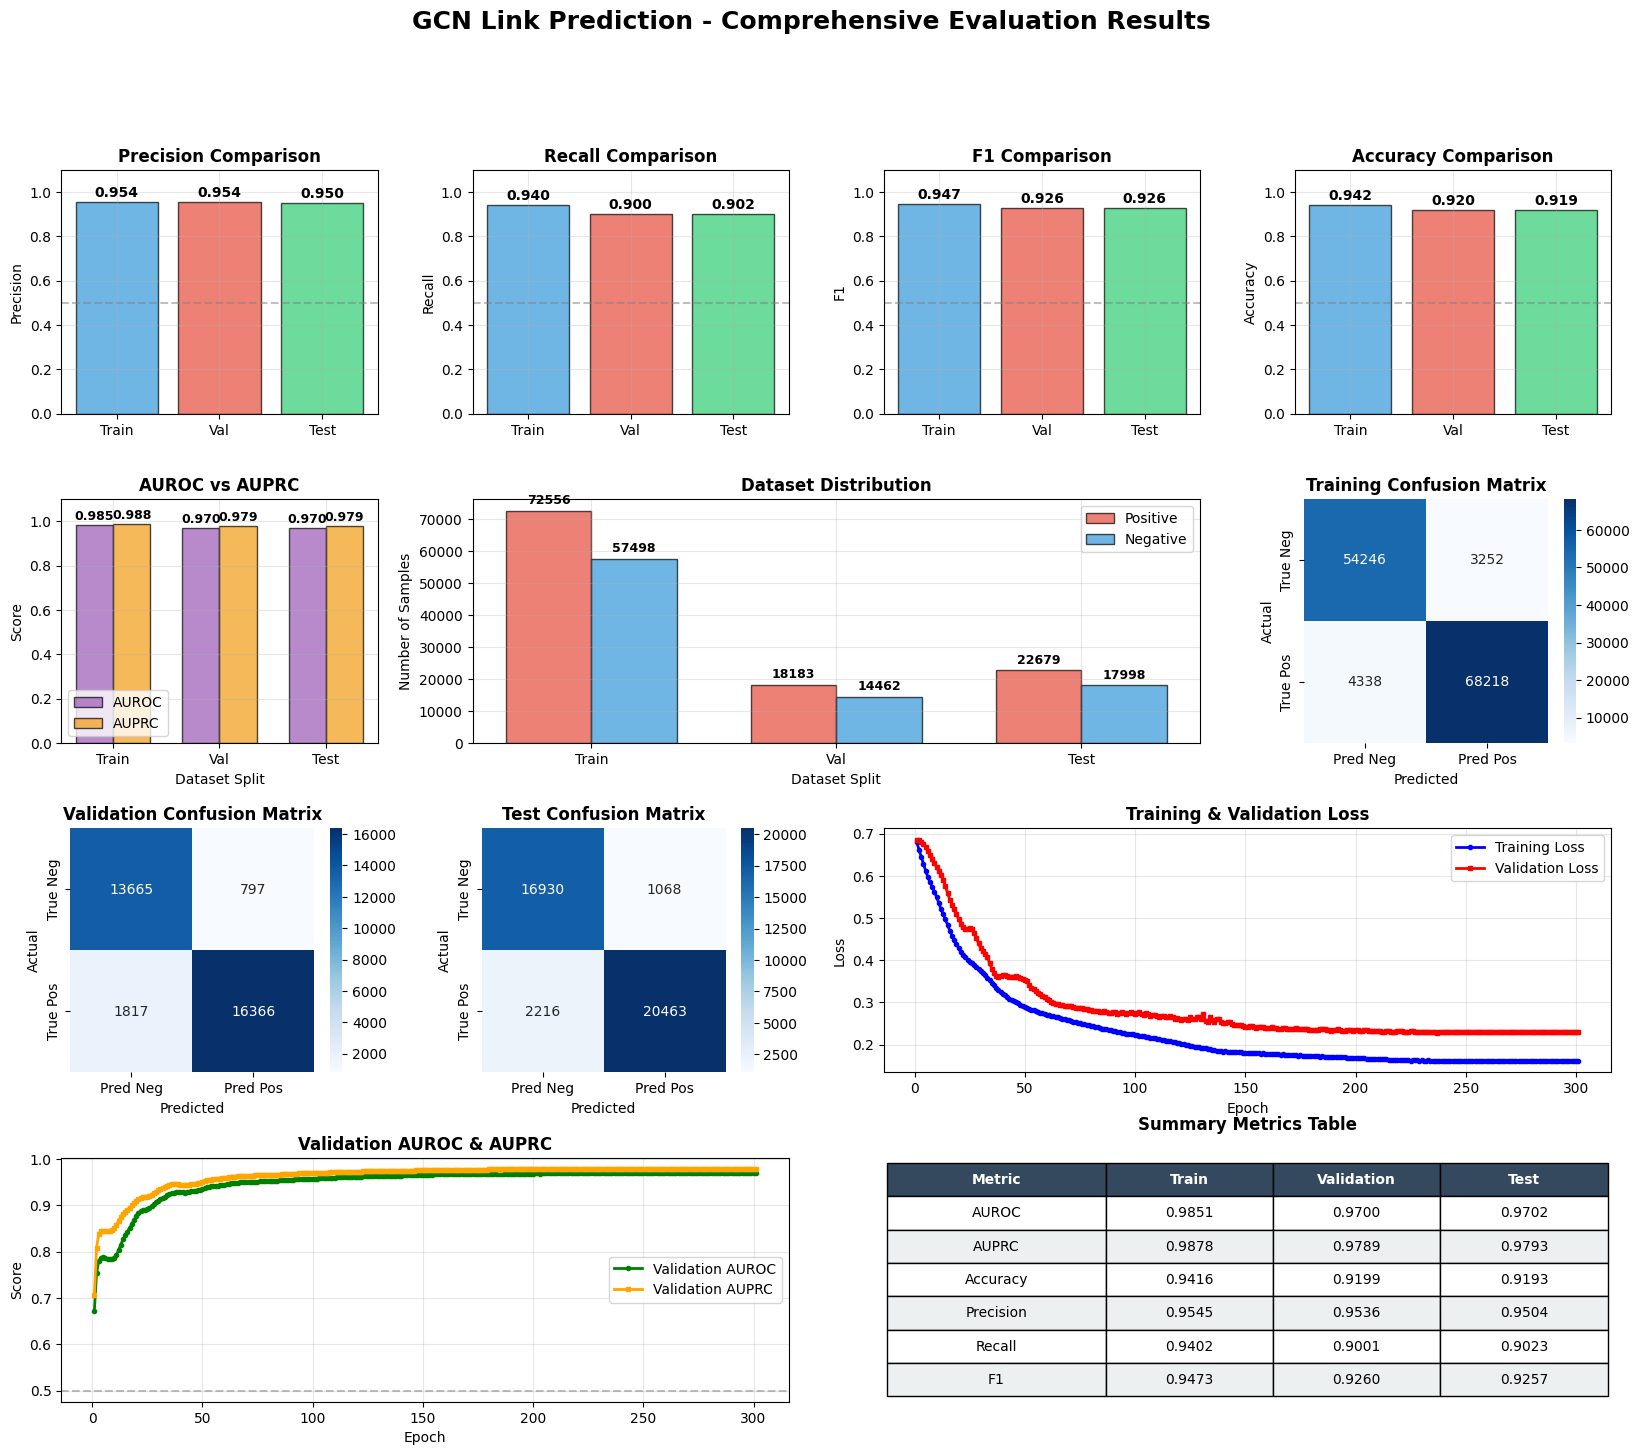

ROC/PR curves saved to: gcn_curves.png


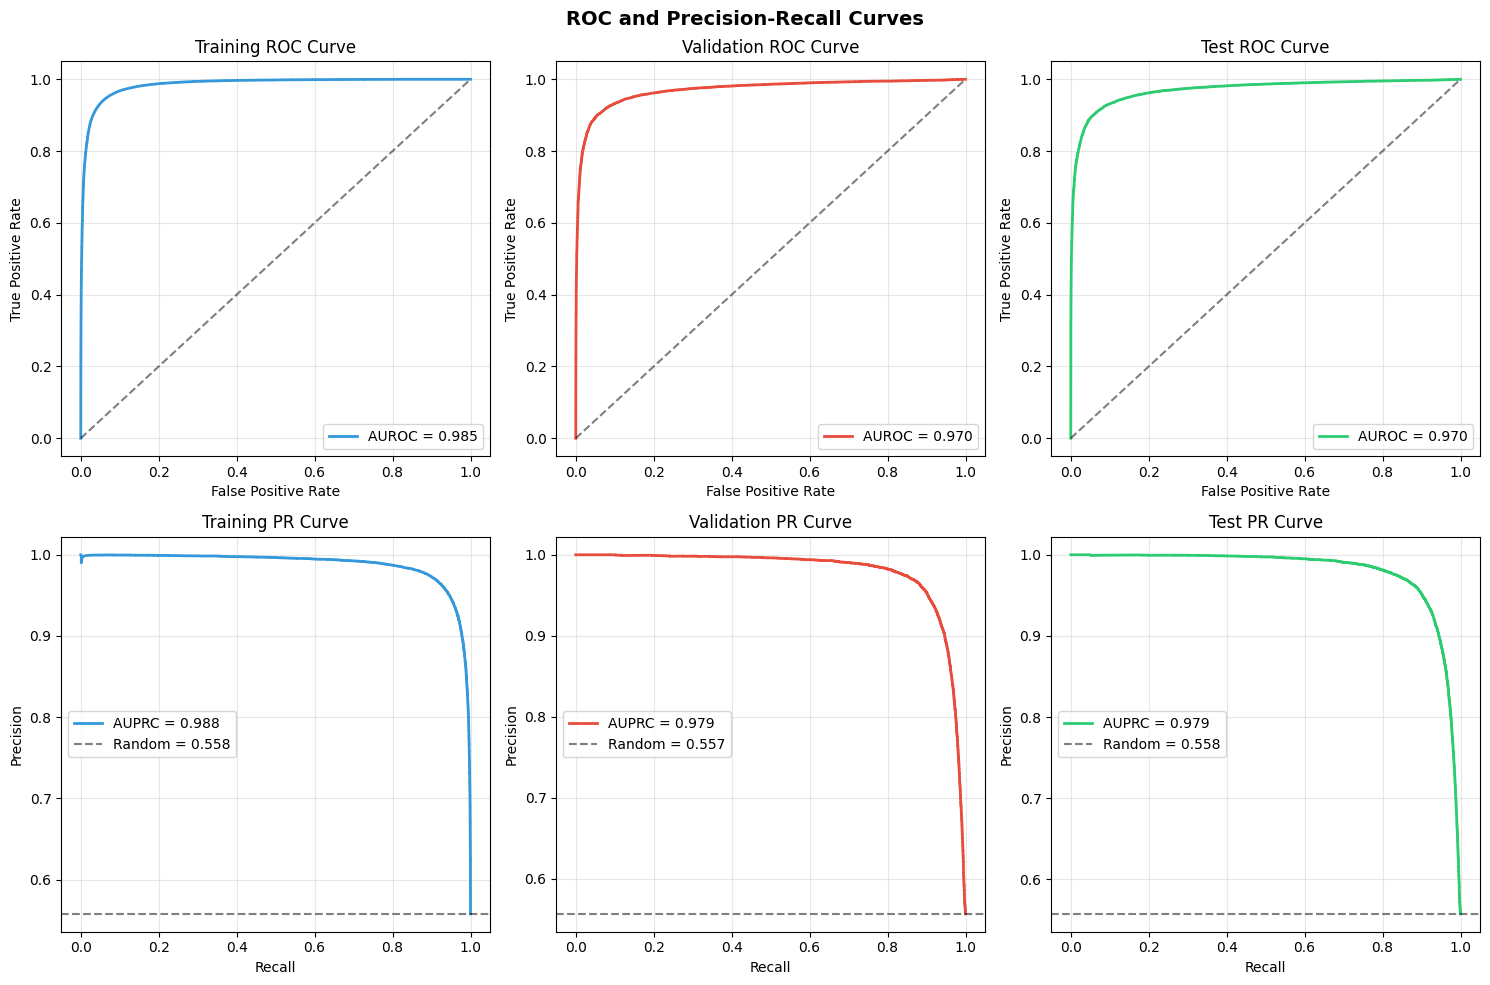

Confusion matrices saved to: gcn_matrices.png


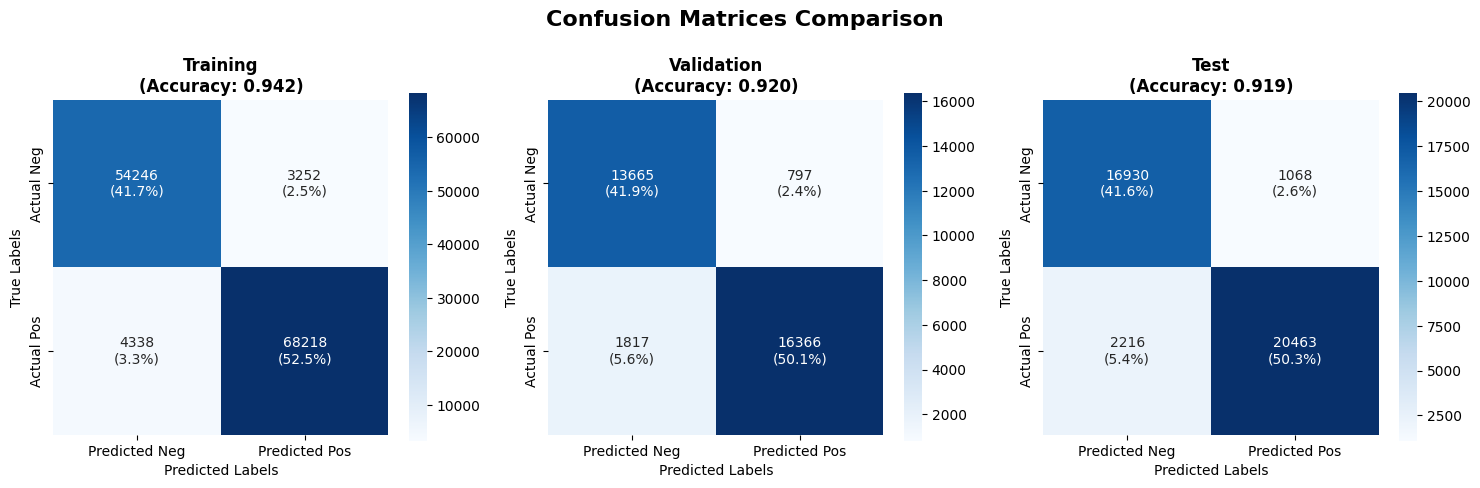

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.nn import GATConv, SAGEConv, GATv2Conv
from torch_geometric.nn import BatchNorm, LayerNorm
from sklearn.metrics import (
    roc_auc_score, average_precision_score, accuracy_score, 
    precision_recall_fscore_support, confusion_matrix,
    precision_recall_curve, roc_curve
)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

class GCNLinkPredictor(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels=64, dropout=0.1):
        super(GCNLinkPredictor, self).__init__()
        
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.bn1 = BatchNorm(hidden_channels)
        
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.bn2 = BatchNorm(hidden_channels)
        
        self.conv3 = GCNConv(hidden_channels, out_channels)

        self.decoder = nn.Sequential(
            nn.Linear(out_channels * 2, 128),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            
            nn.Linear(64, 1)
        )
        
        self.dropout = dropout

    def encode(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = x.relu()
        x = F.dropout(x, p=self.dropout, training=self.training)
        
        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = x.relu()
        x = F.dropout(x, p=self.dropout, training=self.training)
        
        x = self.conv3(x, edge_index)
        return x

    def decode(self, z, edge_label_index):
        z_src = z[edge_label_index[0]]
        z_dst = z[edge_label_index[1]]
        edge_rep = torch.cat([z_src, z_dst], dim=-1)
        return self.decoder(edge_rep).squeeze(-1)

    def forward(self, x, edge_index, edge_label_index):
        z = self.encode(x, edge_index)
        return self.decode(z, edge_label_index)

def compute_loss(pred, label):
    return F.binary_cross_entropy_with_logits(pred, label.float())


def find_optimal_threshold(y_true, y_prob):
    """Find optimal threshold using Youden's J statistic"""
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    j_scores = tpr - fpr
    optimal_idx = np.argmax(j_scores)
    return thresholds[optimal_idx]


@torch.no_grad()
def compute_metrics(pred, label, threshold=None):
    """Compute evaluation metrics using sklearn"""
    prob = torch.sigmoid(pred).detach().cpu().numpy()
    label = label.detach().cpu().numpy()
    
    if threshold is None:
        threshold = find_optimal_threshold(label, prob)
    
    pred_binary = (prob >= threshold).astype(int)
    
    auroc = roc_auc_score(label, prob)
    auprc = average_precision_score(label, prob)
    accuracy = accuracy_score(label, pred_binary)
    
    precision, recall, f1, _ = precision_recall_fscore_support(
        label, pred_binary, average='binary', zero_division=0
    )

    tn, fp, fn, tp = confusion_matrix(label, pred_binary).ravel()

    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    return {
        "AUROC": auroc,
        "AUPRC": auprc,

        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "Specificity": specificity,
        "F1": f1,

        "TP": int(tp),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),

        "Threshold": threshold,
        "Total_Samples": len(label),
        "Positive_Samples": int(np.sum(label)),
        "Negative_Samples": int(len(label) - np.sum(label))
    }


def print_metrics(metrics, dataset_name=""):
    """Print metrics in a clean format"""
    print(f"{dataset_name} METRICS")
    print(f"{'='*50}")
    
    print(f"THRESHOLD-INDEPENDENT:")
    print(f"   AUROC:           {metrics['AUROC']:.4f}")
    print(f"   AUPRC:           {metrics['AUPRC']:.4f}")
    
    print(f"\nCLASSIFICATION (Threshold: {metrics['Threshold']:.4f}):")
    print(f"   Accuracy:        {metrics['Accuracy']:.4f}")
    print(f"   Precision:       {metrics['Precision']:.4f}")
    print(f"   Recall:          {metrics['Recall']:.4f}")
    print(f"   Specificity:     {metrics['Specificity']:.4f}")
    print(f"   F1-Score:        {metrics['F1']:.4f}")
    
    print(f"\nCONFUSION MATRIX:")
    print(f"   True Pos (TP):   {metrics['TP']}")
    print(f"   True Neg (TN):   {metrics['TN']}")
    print(f"   False Pos (FP):  {metrics['FP']}")
    print(f"   False Neg (FN):  {metrics['FN']}")
    
    print(f"\nDATASET INFO:")
    print(f"   Total:           {metrics['Total_Samples']}")
    print(f"   Positive:        {metrics['Positive_Samples']} ({metrics['Positive_Samples']/metrics['Total_Samples']*100:.1f}%)")
    print(f"   Negative:        {metrics['Negative_Samples']} ({metrics['Negative_Samples']/metrics['Total_Samples']*100:.1f}%)")


def train(model, data, optimizer):
    model.train()
    optimizer.zero_grad()
    pred = model(data.x, data.edge_index, data.edge_label_index)
    loss = compute_loss(pred, data.edge_label)
    loss.backward()
    optimizer.step()
    return loss.item()


@torch.no_grad()
def evaluate(model, data, compute_detailed=False):
    model.eval()
    pred = model(data.x, data.edge_index, data.edge_label_index)
    loss = compute_loss(pred, data.edge_label)
    
    if compute_detailed:
        metrics = compute_metrics(pred, data.edge_label)
        return loss.item(), metrics
    else:
        # Quick metrics for training loop
        prob = torch.sigmoid(pred).detach().cpu().numpy()
        label = data.edge_label.detach().cpu().numpy()
        quick_metrics = {
            "AUROC": roc_auc_score(label, prob),
            "AUPRC": average_precision_score(label, prob)
        }
        return loss.item(), quick_metrics


def run_training(model, data_train, data_val, data_test, optimizer, 
                max_epochs=400, patience=10):
    """Training loop with comprehensive evaluation"""

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=5, verbose=True
    )
    
    best_val_auc = 0
    patience_counter = 0
    best_model_state = None

    training_history = {
        'train_loss': [],
        'val_loss': [], 
        'val_auroc': [],
        'val_auprc': []
    }
    
    for epoch in range(1, max_epochs + 1):
        train_loss = train(model, data_train, optimizer)
        val_loss, val_metrics = evaluate(model, data_val, compute_detailed=False)
        val_auc = val_metrics["AUROC"]
        val_auprc = val_metrics["AUPRC"]

        scheduler.step(val_auc)
        
        training_history['train_loss'].append(train_loss)
        training_history['val_loss'].append(val_loss)
        training_history['val_auroc'].append(val_auc)
        training_history['val_auprc'].append(val_auprc)

        print(f"Epoch {epoch:03d} | Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val AUROC: {val_auc:.4f} | Val AUPRC: {val_auprc:.4f}")

        if val_auc > best_val_auc:
            best_val_auc = val_auc
            patience_counter = 0
            best_model_state = model.state_dict()
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch}. Best Val AUROC: {best_val_auc:.4f}")
            break

    # Load best model and evaluate
    print("\nLoading best model for evaluation...")
    model.load_state_dict(best_model_state)
    
    # Final evaluation
    train_loss, train_metrics = evaluate(model, data_train, compute_detailed=True)
    val_loss, val_metrics = evaluate(model, data_val, compute_detailed=True) 
    test_loss, test_metrics = evaluate(model, data_test, compute_detailed=True)
    
    print_metrics(train_metrics, "TRAINING")
    print_metrics(val_metrics, "VALIDATION") 
    print_metrics(test_metrics, "TEST")
    
    print(f"SUMMARY TABLE")
    print(f"{'='*70}")
    print(f"{'Metric':<15} {'Train':<12} {'Validation':<12} {'Test':<12}")
    print(f"{'-'*55}")
    for metric in ['AUROC', 'AUPRC', 'Accuracy', 'Precision', 'Recall', 'F1']:
        print(f"{metric:<15} {train_metrics[metric]:<12.4f} {val_metrics[metric]:<12.4f} {test_metrics[metric]:<12.4f}")
    
    return model, train_metrics, val_metrics, test_metrics, training_history


def plot_results(train_metrics, val_metrics, test_metrics, training_history=None, save_path=None):
    """Create comprehensive plots for evaluation results with proper layout"""
    plt.style.use('default')
    sns.set_palette("husl")

    fig = plt.figure(figsize=(20, 16))

    gs = GridSpec(4, 4, figure=fig, hspace=0.35, wspace=0.3)

    colors = ['#3498db', '#e74c3c', '#2ecc71']
    splits = ['Train', 'Val', 'Test']
    split_metrics = [train_metrics, val_metrics, test_metrics]
    
    metrics_to_plot = ['Precision', 'Recall', 'F1', 'Accuracy']
    
    for i, metric in enumerate(metrics_to_plot):
        ax = fig.add_subplot(gs[0, i])
        values = [split_metric[metric] for split_metric in split_metrics]
        bars = ax.bar(splits, values, color=colors, alpha=0.7, edgecolor='black', linewidth=1)
        
        for bar, value in zip(bars, values):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                   f'{value:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
        
        ax.set_title(f'{metric} Comparison', fontsize=12, fontweight='bold')
        ax.set_ylabel(metric, fontsize=10)
        ax.set_ylim(0, 1.1)
        ax.grid(True, alpha=0.3)
        ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
    
    ax = fig.add_subplot(gs[1, 0])
    auroc_values = [split_data['AUROC'] for split_data in split_metrics]
    auprc_values = [split_data['AUPRC'] for split_data in split_metrics]
    
    x = np.arange(len(splits))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, auroc_values, width, label='AUROC', color='#9b59b6', alpha=0.7, edgecolor='black')
    bars2 = ax.bar(x + width/2, auprc_values, width, label='AUPRC', color='#f39c12', alpha=0.7, edgecolor='black')

    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                   f'{height:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
    
    ax.set_xlabel('Dataset Split')
    ax.set_ylabel('Score')
    ax.set_title('AUROC vs AUPRC', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(splits)
    ax.set_ylim(0, 1.1)
    ax.legend()
    ax.grid(True, alpha=0.3)

    ax = fig.add_subplot(gs[1, 1:3])
    total_samples = [m['Total_Samples'] for m in split_metrics]
    pos_samples = [m['Positive_Samples'] for m in split_metrics]
    neg_samples = [m['Negative_Samples'] for m in split_metrics]
    
    x = np.arange(len(splits))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, pos_samples, width, label='Positive', color='#e74c3c', alpha=0.7, edgecolor='black')
    bars2 = ax.bar(x + width/2, neg_samples, width, label='Negative', color='#3498db', alpha=0.7, edgecolor='black')

    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + max(total_samples)*0.01,
                   f'{int(height)}', ha='center', va='bottom', fontweight='bold', fontsize=9)
    
    ax.set_xlabel('Dataset Split')
    ax.set_ylabel('Number of Samples')
    ax.set_title('Dataset Distribution', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(splits)
    ax.legend()
    ax.grid(True, alpha=0.3)

    cm_positions = [(1, 3), (2, 0), (2, 1)]
    cm_titles = ['Training', 'Validation', 'Test']
    
    for idx, (split_metrics_data, title, pos) in enumerate(zip(split_metrics, cm_titles, cm_positions)):
        ax = fig.add_subplot(gs[pos[0], pos[1]])
        
        cm_data = np.array([[split_metrics_data['TN'], split_metrics_data['FP']],
                           [split_metrics_data['FN'], split_metrics_data['TP']]])

        sns.heatmap(cm_data, annot=True, fmt='d', cmap='Blues', 
                   xticklabels=['Pred Neg', 'Pred Pos'],
                   yticklabels=['True Neg', 'True Pos'],
                   ax=ax, cbar=True, square=True)
        
        ax.set_title(f'{title} Confusion Matrix', fontweight='bold')
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')

    if training_history is not None:
        ax1 = fig.add_subplot(gs[2, 2:4])
        epochs = range(1, len(training_history['train_loss']) + 1)
        
        ax1.plot(epochs, training_history['train_loss'], 'b-', label='Training Loss', linewidth=2, marker='o', markersize=3)
        ax1.plot(epochs, training_history['val_loss'], 'r-', label='Validation Loss', linewidth=2, marker='s', markersize=3)
        
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Loss')
        ax1.set_title('Training & Validation Loss', fontweight='bold')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        ax2 = fig.add_subplot(gs[3, 0:2])
        ax2.plot(epochs, training_history['val_auroc'], 'g-', label='Validation AUROC', linewidth=2, marker='o', markersize=3)
        ax2.plot(epochs, training_history['val_auprc'], 'orange', label='Validation AUPRC', linewidth=2, marker='s', markersize=3)
        
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('Score')
        ax2.set_title('Validation AUROC & AUPRC', fontweight='bold')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        ax2.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random (0.5)')

        ax3 = fig.add_subplot(gs[3, 2:4])
        ax3.axis('off')

        table_data = []
        metrics_for_table = ['AUROC', 'AUPRC', 'Accuracy', 'Precision', 'Recall', 'F1']
        
        for metric in metrics_for_table:
            row = [metric, 
                   f"{train_metrics[metric]:.4f}",
                   f"{val_metrics[metric]:.4f}", 
                   f"{test_metrics[metric]:.4f}"]
            table_data.append(row)
        
        table = ax3.table(cellText=table_data,
                         colLabels=['Metric', 'Train', 'Validation', 'Test'],
                         cellLoc='center',
                         loc='center',
                         colWidths=[0.3, 0.23, 0.23, 0.23])
        
        table.auto_set_font_size(False)
        table.set_fontsize(10)
        table.scale(1, 2)

        for i in range(len(metrics_for_table) + 1):
            for j in range(4):
                cell = table[(i, j)]
                if i == 0:  # Header row
                    cell.set_facecolor('#34495e')
                    cell.set_text_props(weight='bold', color='white')
                else:
                    cell.set_facecolor('#ecf0f1' if i % 2 == 0 else 'white')
                    cell.set_text_props(weight='normal')
        
        ax3.set_title('Summary Metrics Table', fontweight='bold', pad=20)
    
    else:
        ax3 = fig.add_subplot(gs[2:4, 2:4])
        ax3.axis('off')
        
        table_data = []
        all_metrics = ['AUROC', 'AUPRC', 'Accuracy', 'Precision', 'Recall', 'Specificity', 'F1']
        
        for metric in all_metrics:
            row = [metric, 
                   f"{train_metrics[metric]:.4f}",
                   f"{val_metrics[metric]:.4f}", 
                   f"{test_metrics[metric]:.4f}"]
            table_data.append(row)
        
        table = ax3.table(cellText=table_data,
                         colLabels=['Metric', 'Train', 'Validation', 'Test'],
                         cellLoc='center',
                         loc='center',
                         colWidths=[0.3, 0.23, 0.23, 0.23])
        
        table.auto_set_font_size(False)
        table.set_fontsize(11)
        table.scale(1, 1.8)
        
        for i in range(len(all_metrics) + 1):
            for j in range(4):
                cell = table[(i, j)]
                if i == 0:  
                    cell.set_facecolor('#34495e')
                    cell.set_text_props(weight='bold', color='white')
                else:
                    cell.set_facecolor('#ecf0f1' if i % 2 == 0 else 'white')
                    cell.set_text_props(weight='normal')
        
        ax3.set_title('Comprehensive Metrics Summary', fontweight='bold', pad=20)

    fig.suptitle('GCN Link Prediction - Comprehensive Evaluation Results', 
                 fontsize=18, fontweight='bold', y=0.98)

    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"Plot saved to: {save_path}")
    
    plt.show()


def plot_confusion_matrices(train_metrics, val_metrics, test_metrics, save_path=None):
    """Create a dedicated confusion matrix visualization"""
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle('Confusion Matrices Comparison', fontsize=16, fontweight='bold')
    
    split_metrics = [train_metrics, val_metrics, test_metrics]
    titles = ['Training', 'Validation', 'Test']
    
    for idx, (metrics, title, ax) in enumerate(zip(split_metrics, titles, axes)):
        cm_data = np.array([[metrics['TN'], metrics['FP']],
                           [metrics['FN'], metrics['TP']]])

        cm_percent = cm_data / cm_data.sum() * 100
        
        annotations = np.array([[f"{cm_data[i,j]}\n({cm_percent[i,j]:.1f}%)" 
                               for j in range(2)] for i in range(2)])

        sns.heatmap(cm_data, annot=annotations, fmt='', cmap='Blues', 
                   xticklabels=['Predicted Neg', 'Predicted Pos'],
                   yticklabels=['Actual Neg', 'Actual Pos'],
                   ax=ax, cbar=True, square=True, cbar_kws={'shrink': 0.8})
        
        ax.set_title(f'{title}\n(Accuracy: {metrics["Accuracy"]:.3f})', fontweight='bold')
        ax.set_xlabel('Predicted Labels')
        ax.set_ylabel('True Labels')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"Confusion matrices saved to: {save_path}")
    
    plt.show()

def plot_roc_pr_curves(model, data_train, data_val, data_test, save_path=None):
    """Plot ROC and Precision-Recall curves"""
    model.eval()
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle('ROC and Precision-Recall Curves', fontsize=14, fontweight='bold')
    
    datasets = [
        (data_train, 'Training', '#3498db'),
        (data_val, 'Validation', '#e74c3c'), 
        (data_test, 'Test', '#2ecc71')
    ]
    
    for i, (data, name, color) in enumerate(datasets):
        with torch.no_grad():
            pred = model(data.x, data.edge_index, data.edge_label_index)
            prob = torch.sigmoid(pred).cpu().numpy()
            label = data.edge_label.cpu().numpy()

        fpr, tpr, _ = roc_curve(label, prob)
        auroc = roc_auc_score(label, prob)
        
        axes[0, i].plot(fpr, tpr, color=color, linewidth=2, label=f'AUROC = {auroc:.3f}')
        axes[0, i].plot([0, 1], [0, 1], 'k--', alpha=0.5)
        axes[0, i].set_xlabel('False Positive Rate')
        axes[0, i].set_ylabel('True Positive Rate')
        axes[0, i].set_title(f'{name} ROC Curve')
        axes[0, i].legend()
        axes[0, i].grid(True, alpha=0.3)

        precision, recall, _ = precision_recall_curve(label, prob)
        auprc = average_precision_score(label, prob)
        
        axes[1, i].plot(recall, precision, color=color, linewidth=2, label=f'AUPRC = {auprc:.3f}')
        axes[1, i].axhline(y=np.mean(label), color='k', linestyle='--', alpha=0.5,
                          label=f'Random = {np.mean(label):.3f}')
        axes[1, i].set_xlabel('Recall')
        axes[1, i].set_ylabel('Precision')
        axes[1, i].set_title(f'{name} PR Curve')
        axes[1, i].legend()
        axes[1, i].grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"ROC/PR curves saved to: {save_path}")
    
    plt.show()

if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    model = GCNLinkPredictor(
        in_channels=64,
        hidden_channels=128,
        out_channels=64,
        dropout=0.1
    ).to(device)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

    data_train = train_data.to(device)
    data_val = val_data.to(device)
    data_test = test_data.to(device)

    trained_model, train_results, val_results, test_results, history = run_training(
        model, data_train, data_val, data_test, optimizer,
        max_epochs=400, patience=10
    )

    plot_results(train_results, val_results, test_results, 
                training_history=history, save_path="gcn_results.png")
    plot_roc_pr_curves(trained_model, data_train, data_val, data_test, 
                      save_path="gcn_curves.png")
    plot_confusion_matrices(train_results, val_results, test_results, save_path="gcn_matrices.png")

## === GAT ===

/home/makry/A Graph-based Approach to Efficiently Predicting Protein-Protein Interactions/gnn/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


Epoch 001 | Train Loss: 0.6895 | Val Loss: 0.6914 | Val AUROC: 0.7018 | Val AUPRC: 0.7828
Epoch 002 | Train Loss: 0.6773 | Val Loss: 0.6907 | Val AUROC: 0.7155 | Val AUPRC: 0.7906
Epoch 003 | Train Loss: 0.6671 | Val Loss: 0.6900 | Val AUROC: 0.7234 | Val AUPRC: 0.7940
Epoch 004 | Train Loss: 0.6566 | Val Loss: 0.6887 | Val AUROC: 0.7315 | Val AUPRC: 0.8073
Epoch 005 | Train Loss: 0.6470 | Val Loss: 0.6868 | Val AUROC: 0.7379 | Val AUPRC: 0.8156
Epoch 006 | Train Loss: 0.6370 | Val Loss: 0.6843 | Val AUROC: 0.7421 | Val AUPRC: 0.8196
Epoch 007 | Train Loss: 0.6270 | Val Loss: 0.6815 | Val AUROC: 0.7450 | Val AUPRC: 0.8219
Epoch 008 | Train Loss: 0.6175 | Val Loss: 0.6783 | Val AUROC: 0.7448 | Val AUPRC: 0.8227
Epoch 009 | Train Loss: 0.6091 | Val Loss: 0.6747 | Val AUROC: 0.7439 | Val AUPRC: 0.8235
Epoch 010 | Train Loss: 0.5986 | Val Loss: 0.6708 | Val AUROC: 0.7432 | Val AUPRC: 0.8240
Epoch 011 | Train Loss: 0.5892 | Val Loss: 0.6663 | Val AUROC: 0.7423 | Val AUPRC: 0.8241
Epoch 012 

/tmp/ipykernel_11433/1297193525.py:437: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Plot saved to: gat_results.png


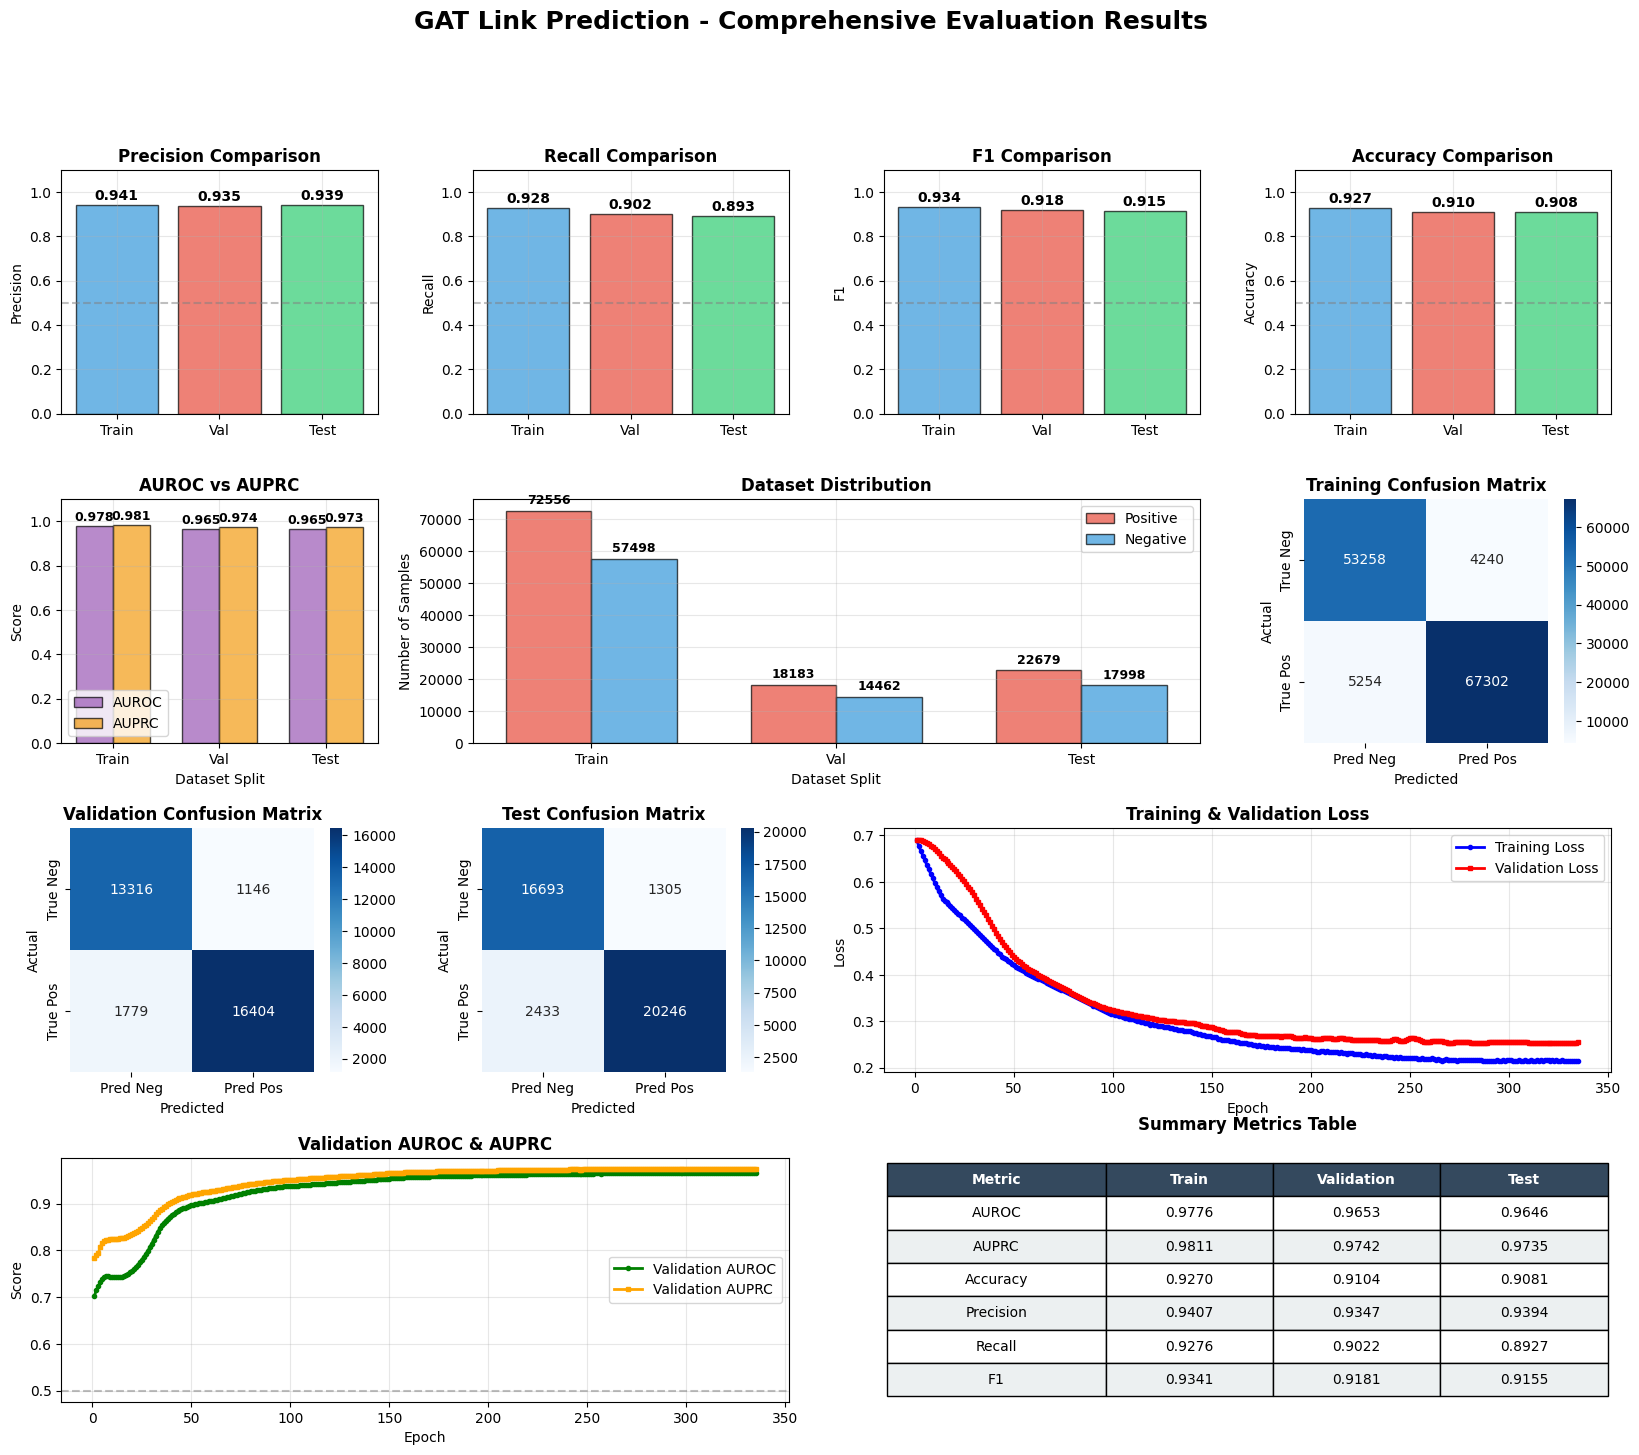

ROC/PR curves saved to: gat_curves.png


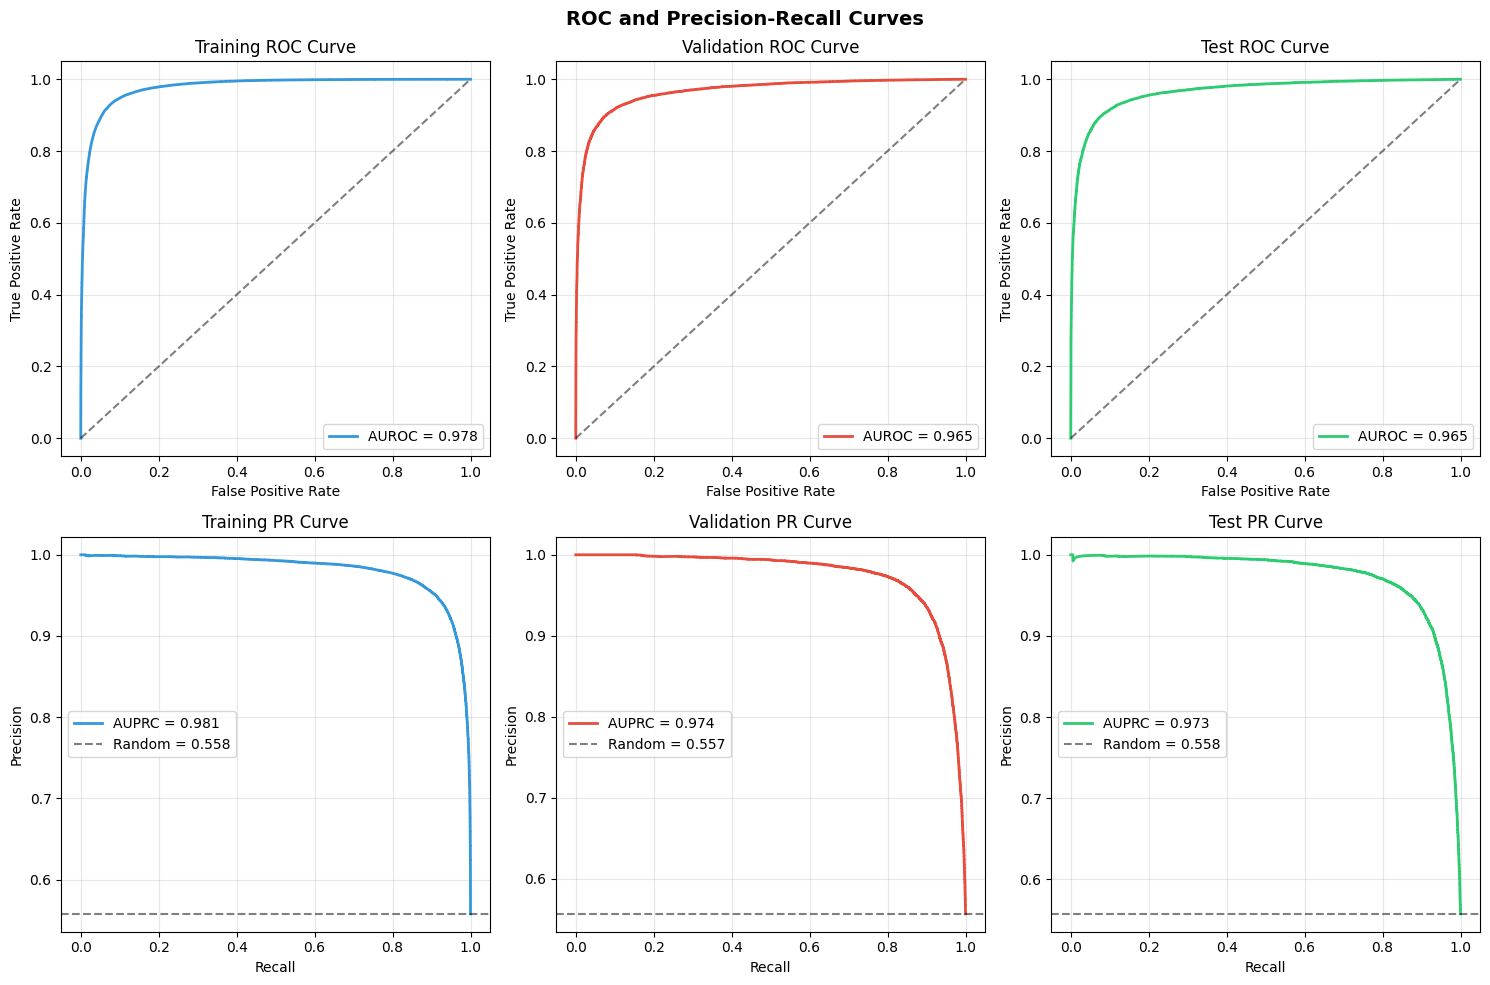

Confusion matrices saved to: gat_matrices.png


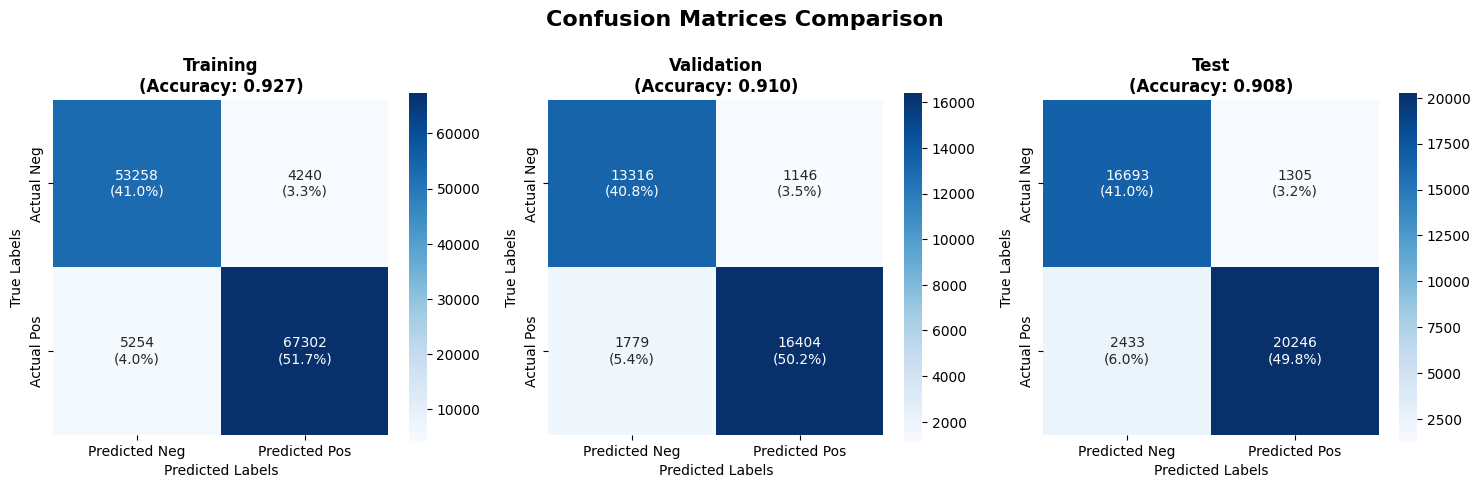

In [27]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv, SAGEConv, GATv2Conv
from torch_geometric.nn import BatchNorm, LayerNorm
from sklearn.metrics import (
    roc_auc_score, average_precision_score, accuracy_score, 
    precision_recall_fscore_support, confusion_matrix,
    precision_recall_curve, roc_curve
)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec


class GATLinkPredictor(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels=64, dropout=0.2, heads=8):
        super(GATLinkPredictor, self).__init__()
        self.heads = heads
        self.dropout = dropout
        
        self.gat1 = GATv2Conv(in_channels, hidden_channels // heads, heads=heads, dropout=dropout)
        self.bn1 = BatchNorm(hidden_channels)

        self.gat2 = GATv2Conv(hidden_channels, out_channels, heads=1, dropout=dropout)
        self.bn2 = BatchNorm(out_channels)

        self.decoder = nn.Sequential(
            nn.Linear(out_channels * 2, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )
    
    def encode(self, x, edge_index):
        x = self.gat1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.gat2(x, edge_index)
        x = self.bn2(x)
        return x
    
    def decode(self, z, edge_label_index):
        z_src = z[edge_label_index[0]]
        z_dst = z[edge_label_index[1]]
        edge_rep = torch.cat([z_src, z_dst], dim=-1)
        return self.decoder(edge_rep).squeeze(-1)
    
    def forward(self, x, edge_index, edge_label_index):
        z = self.encode(x, edge_index)
        return self.decode(z, edge_label_index)

def compute_loss(pred, label):
    return F.binary_cross_entropy_with_logits(pred, label.float())


def find_optimal_threshold(y_true, y_prob):
    """Find optimal threshold using Youden's J statistic"""
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    j_scores = tpr - fpr
    optimal_idx = np.argmax(j_scores)
    return thresholds[optimal_idx]


@torch.no_grad()
def compute_metrics(pred, label, threshold=None):
    """Compute evaluation metrics using sklearn"""
    prob = torch.sigmoid(pred).detach().cpu().numpy()
    label = label.detach().cpu().numpy()

    if threshold is None:
        threshold = find_optimal_threshold(label, prob)

    pred_binary = (prob >= threshold).astype(int)

    auroc = roc_auc_score(label, prob)
    auprc = average_precision_score(label, prob)
    accuracy = accuracy_score(label, pred_binary)

    precision, recall, f1, _ = precision_recall_fscore_support(
        label, pred_binary, average='binary', zero_division=0
    )

    tn, fp, fn, tp = confusion_matrix(label, pred_binary).ravel()

    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    return {
        "AUROC": auroc,
        "AUPRC": auprc,

        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "Specificity": specificity,
        "F1": f1,

        "TP": int(tp),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),

        "Threshold": threshold,
        "Total_Samples": len(label),
        "Positive_Samples": int(np.sum(label)),
        "Negative_Samples": int(len(label) - np.sum(label))
    }


def print_metrics(metrics, dataset_name=""):
    """Print metrics in a clean format"""
    print(f"{dataset_name} METRICS")
    print(f"{'='*50}")
    
    print(f"THRESHOLD-INDEPENDENT:")
    print(f"   AUROC:           {metrics['AUROC']:.4f}")
    print(f"   AUPRC:           {metrics['AUPRC']:.4f}")
    
    print(f"\nCLASSIFICATION (Threshold: {metrics['Threshold']:.4f}):")
    print(f"   Accuracy:        {metrics['Accuracy']:.4f}")
    print(f"   Precision:       {metrics['Precision']:.4f}")
    print(f"   Recall:          {metrics['Recall']:.4f}")
    print(f"   Specificity:     {metrics['Specificity']:.4f}")
    print(f"   F1-Score:        {metrics['F1']:.4f}")
    
    print(f"\nCONFUSION MATRIX:")
    print(f"   True Pos (TP):   {metrics['TP']}")
    print(f"   True Neg (TN):   {metrics['TN']}")
    print(f"   False Pos (FP):  {metrics['FP']}")
    print(f"   False Neg (FN):  {metrics['FN']}")
    
    print(f"\nDATASET INFO:")
    print(f"   Total:           {metrics['Total_Samples']}")
    print(f"   Positive:        {metrics['Positive_Samples']} ({metrics['Positive_Samples']/metrics['Total_Samples']*100:.1f}%)")
    print(f"   Negative:        {metrics['Negative_Samples']} ({metrics['Negative_Samples']/metrics['Total_Samples']*100:.1f}%)")


def train(model, data, optimizer):
    model.train()
    optimizer.zero_grad()
    pred = model(data.x, data.edge_index, data.edge_label_index)
    loss = compute_loss(pred, data.edge_label)
    loss.backward()
    optimizer.step()
    return loss.item()


@torch.no_grad()
def evaluate(model, data, compute_detailed=False):
    model.eval()
    pred = model(data.x, data.edge_index, data.edge_label_index)
    loss = compute_loss(pred, data.edge_label)
    
    if compute_detailed:
        metrics = compute_metrics(pred, data.edge_label)
        return loss.item(), metrics
    else:
        prob = torch.sigmoid(pred).detach().cpu().numpy()
        label = data.edge_label.detach().cpu().numpy()
        quick_metrics = {
            "AUROC": roc_auc_score(label, prob),
            "AUPRC": average_precision_score(label, prob)
        }
        return loss.item(), quick_metrics


def run_training(model, data_train, data_val, data_test, optimizer, 
                max_epochs=400, patience=10):
    """Training loop with comprehensive evaluation"""

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=5, verbose=True
    )
    
    best_val_auc = 0
    patience_counter = 0
    best_model_state = None

    training_history = {
        'train_loss': [],
        'val_loss': [], 
        'val_auroc': [],
        'val_auprc': []
    }
    
    for epoch in range(1, max_epochs + 1):
        train_loss = train(model, data_train, optimizer)
        val_loss, val_metrics = evaluate(model, data_val, compute_detailed=False)
        val_auc = val_metrics["AUROC"]
        val_auprc = val_metrics["AUPRC"]

        scheduler.step(val_auc)

        training_history['train_loss'].append(train_loss)
        training_history['val_loss'].append(val_loss)
        training_history['val_auroc'].append(val_auc)
        training_history['val_auprc'].append(val_auprc)

        print(f"Epoch {epoch:03d} | Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val AUROC: {val_auc:.4f} | Val AUPRC: {val_auprc:.4f}")

        if val_auc > best_val_auc:
            best_val_auc = val_auc
            patience_counter = 0
            best_model_state = model.state_dict()
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch}. Best Val AUROC: {best_val_auc:.4f}")
            break

    print("\nLoading best model for evaluation...")
    model.load_state_dict(best_model_state)

    train_loss, train_metrics = evaluate(model, data_train, compute_detailed=True)
    val_loss, val_metrics = evaluate(model, data_val, compute_detailed=True) 
    test_loss, test_metrics = evaluate(model, data_test, compute_detailed=True)

    print_metrics(train_metrics, "TRAINING")
    print_metrics(val_metrics, "VALIDATION") 
    print_metrics(test_metrics, "TEST")

    print(f"\n{'='*70}")
    print(f"SUMMARY TABLE")
    print(f"{'='*70}")
    print(f"{'Metric':<15} {'Train':<12} {'Validation':<12} {'Test':<12}")
    print(f"{'-'*55}")
    for metric in ['AUROC', 'AUPRC', 'Accuracy', 'Precision', 'Recall', 'F1']:
        print(f"{metric:<15} {train_metrics[metric]:<12.4f} {val_metrics[metric]:<12.4f} {test_metrics[metric]:<12.4f}")
    
    return model, train_metrics, val_metrics, test_metrics, training_history


def plot_results(train_metrics, val_metrics, test_metrics, training_history=None, save_path=None):
    """Create comprehensive plots for evaluation results with proper layout"""
    plt.style.use('default')
    sns.set_palette("husl")

    fig = plt.figure(figsize=(20, 16))
    gs = GridSpec(4, 4, figure=fig, hspace=0.35, wspace=0.3)

    colors = ['#3498db', '#e74c3c', '#2ecc71']
    splits = ['Train', 'Val', 'Test']
    split_metrics = [train_metrics, val_metrics, test_metrics]

    metrics_to_plot = ['Precision', 'Recall', 'F1', 'Accuracy']
    
    for i, metric in enumerate(metrics_to_plot):
        ax = fig.add_subplot(gs[0, i])
        values = [split_metric[metric] for split_metric in split_metrics]
        bars = ax.bar(splits, values, color=colors, alpha=0.7, edgecolor='black', linewidth=1)

        for bar, value in zip(bars, values):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                   f'{value:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
        
        ax.set_title(f'{metric} Comparison', fontsize=12, fontweight='bold')
        ax.set_ylabel(metric, fontsize=10)
        ax.set_ylim(0, 1.1)
        ax.grid(True, alpha=0.3)
        ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)

    ax = fig.add_subplot(gs[1, 0])
    auroc_values = [split_data['AUROC'] for split_data in split_metrics]
    auprc_values = [split_data['AUPRC'] for split_data in split_metrics]
    
    x = np.arange(len(splits))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, auroc_values, width, label='AUROC', color='#9b59b6', alpha=0.7, edgecolor='black')
    bars2 = ax.bar(x + width/2, auprc_values, width, label='AUPRC', color='#f39c12', alpha=0.7, edgecolor='black')

    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                   f'{height:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
    
    ax.set_xlabel('Dataset Split')
    ax.set_ylabel('Score')
    ax.set_title('AUROC vs AUPRC', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(splits)
    ax.set_ylim(0, 1.1)
    ax.legend()
    ax.grid(True, alpha=0.3)

    ax = fig.add_subplot(gs[1, 1:3])
    total_samples = [m['Total_Samples'] for m in split_metrics]
    pos_samples = [m['Positive_Samples'] for m in split_metrics]
    neg_samples = [m['Negative_Samples'] for m in split_metrics]
    
    x = np.arange(len(splits))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, pos_samples, width, label='Positive', color='#e74c3c', alpha=0.7, edgecolor='black')
    bars2 = ax.bar(x + width/2, neg_samples, width, label='Negative', color='#3498db', alpha=0.7, edgecolor='black')

    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + max(total_samples)*0.01,
                   f'{int(height)}', ha='center', va='bottom', fontweight='bold', fontsize=9)
    
    ax.set_xlabel('Dataset Split')
    ax.set_ylabel('Number of Samples')
    ax.set_title('Dataset Distribution', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(splits)
    ax.legend()
    ax.grid(True, alpha=0.3)

    cm_positions = [(1, 3), (2, 0), (2, 1)]
    cm_titles = ['Training', 'Validation', 'Test']
    
    for idx, (split_metrics_data, title, pos) in enumerate(zip(split_metrics, cm_titles, cm_positions)):
        ax = fig.add_subplot(gs[pos[0], pos[1]])

        cm_data = np.array([[split_metrics_data['TN'], split_metrics_data['FP']],
                           [split_metrics_data['FN'], split_metrics_data['TP']]])

        sns.heatmap(cm_data, annot=True, fmt='d', cmap='Blues', 
                   xticklabels=['Pred Neg', 'Pred Pos'],
                   yticklabels=['True Neg', 'True Pos'],
                   ax=ax, cbar=True, square=True)
        
        ax.set_title(f'{title} Confusion Matrix', fontweight='bold')
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')

    if training_history is not None:
        ax1 = fig.add_subplot(gs[2, 2:4])
        epochs = range(1, len(training_history['train_loss']) + 1)
        
        ax1.plot(epochs, training_history['train_loss'], 'b-', label='Training Loss', linewidth=2, marker='o', markersize=3)
        ax1.plot(epochs, training_history['val_loss'], 'r-', label='Validation Loss', linewidth=2, marker='s', markersize=3)
        
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Loss')
        ax1.set_title('Training & Validation Loss', fontweight='bold')
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        ax2 = fig.add_subplot(gs[3, 0:2])
        ax2.plot(epochs, training_history['val_auroc'], 'g-', label='Validation AUROC', linewidth=2, marker='o', markersize=3)
        ax2.plot(epochs, training_history['val_auprc'], 'orange', label='Validation AUPRC', linewidth=2, marker='s', markersize=3)
        
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('Score')
        ax2.set_title('Validation AUROC & AUPRC', fontweight='bold')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        ax2.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random (0.5)')

        ax3 = fig.add_subplot(gs[3, 2:4])
        ax3.axis('off')

        table_data = []
        metrics_for_table = ['AUROC', 'AUPRC', 'Accuracy', 'Precision', 'Recall', 'F1']
        
        for metric in metrics_for_table:
            row = [metric, 
                   f"{train_metrics[metric]:.4f}",
                   f"{val_metrics[metric]:.4f}", 
                   f"{test_metrics[metric]:.4f}"]
            table_data.append(row)
        
        table = ax3.table(cellText=table_data,
                         colLabels=['Metric', 'Train', 'Validation', 'Test'],
                         cellLoc='center',
                         loc='center',
                         colWidths=[0.3, 0.23, 0.23, 0.23])
        
        table.auto_set_font_size(False)
        table.set_fontsize(10)
        table.scale(1, 2)

        for i in range(len(metrics_for_table) + 1):
            for j in range(4):
                cell = table[(i, j)]
                if i == 0:  
                    cell.set_facecolor('#34495e')
                    cell.set_text_props(weight='bold', color='white')
                else:
                    cell.set_facecolor('#ecf0f1' if i % 2 == 0 else 'white')
                    cell.set_text_props(weight='normal')
        
        ax3.set_title('Summary Metrics Table', fontweight='bold', pad=20)
    
    else:
        ax3 = fig.add_subplot(gs[2:4, 2:4])
        ax3.axis('off')

        table_data = []
        all_metrics = ['AUROC', 'AUPRC', 'Accuracy', 'Precision', 'Recall', 'Specificity', 'F1']
        
        for metric in all_metrics:
            row = [metric, 
                   f"{train_metrics[metric]:.4f}",
                   f"{val_metrics[metric]:.4f}", 
                   f"{test_metrics[metric]:.4f}"]
            table_data.append(row)
        
        table = ax3.table(cellText=table_data,
                         colLabels=['Metric', 'Train', 'Validation', 'Test'],
                         cellLoc='center',
                         loc='center',
                         colWidths=[0.3, 0.23, 0.23, 0.23])
        
        table.auto_set_font_size(False)
        table.set_fontsize(11)
        table.scale(1, 1.8)

        for i in range(len(all_metrics) + 1):
            for j in range(4):
                cell = table[(i, j)]
                if i == 0: 
                    cell.set_facecolor('#34495e')
                    cell.set_text_props(weight='bold', color='white')
                else:
                    cell.set_facecolor('#ecf0f1' if i % 2 == 0 else 'white')
                    cell.set_text_props(weight='normal')
        
        ax3.set_title('Comprehensive Metrics Summary', fontweight='bold', pad=20)

    fig.suptitle('GAT Link Prediction - Comprehensive Evaluation Results', 
                 fontsize=18, fontweight='bold', y=0.98)

    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"Plot saved to: {save_path}")
    
    plt.show()


def plot_confusion_matrices(train_metrics, val_metrics, test_metrics, save_path=None):
    """Create a dedicated confusion matrix visualization"""
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle('Confusion Matrices Comparison', fontsize=16, fontweight='bold')
    
    split_metrics = [train_metrics, val_metrics, test_metrics]
    titles = ['Training', 'Validation', 'Test']
    
    for idx, (metrics, title, ax) in enumerate(zip(split_metrics, titles, axes)):
        cm_data = np.array([[metrics['TN'], metrics['FP']],
                           [metrics['FN'], metrics['TP']]])
        
        cm_percent = cm_data / cm_data.sum() * 100

        annotations = np.array([[f"{cm_data[i,j]}\n({cm_percent[i,j]:.1f}%)" 
                               for j in range(2)] for i in range(2)])

        sns.heatmap(cm_data, annot=annotations, fmt='', cmap='Blues', 
                   xticklabels=['Predicted Neg', 'Predicted Pos'],
                   yticklabels=['Actual Neg', 'Actual Pos'],
                   ax=ax, cbar=True, square=True, cbar_kws={'shrink': 0.8})
        
        ax.set_title(f'{title}\n(Accuracy: {metrics["Accuracy"]:.3f})', fontweight='bold')
        ax.set_xlabel('Predicted Labels')
        ax.set_ylabel('True Labels')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"Confusion matrices saved to: {save_path}")
    
    plt.show()

def plot_roc_pr_curves(model, data_train, data_val, data_test, save_path=None):
    """Plot ROC and Precision-Recall curves"""
    model.eval()
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle('ROC and Precision-Recall Curves', fontsize=14, fontweight='bold')
    
    datasets = [
        (data_train, 'Training', '#3498db'),
        (data_val, 'Validation', '#e74c3c'), 
        (data_test, 'Test', '#2ecc71')
    ]
    
    for i, (data, name, color) in enumerate(datasets):
        with torch.no_grad():
            pred = model(data.x, data.edge_index, data.edge_label_index)
            prob = torch.sigmoid(pred).cpu().numpy()
            label = data.edge_label.cpu().numpy()

        fpr, tpr, _ = roc_curve(label, prob)
        auroc = roc_auc_score(label, prob)
        
        axes[0, i].plot(fpr, tpr, color=color, linewidth=2, label=f'AUROC = {auroc:.3f}')
        axes[0, i].plot([0, 1], [0, 1], 'k--', alpha=0.5)
        axes[0, i].set_xlabel('False Positive Rate')
        axes[0, i].set_ylabel('True Positive Rate')
        axes[0, i].set_title(f'{name} ROC Curve')
        axes[0, i].legend()
        axes[0, i].grid(True, alpha=0.3)

        precision, recall, _ = precision_recall_curve(label, prob)
        auprc = average_precision_score(label, prob)
        
        axes[1, i].plot(recall, precision, color=color, linewidth=2, label=f'AUPRC = {auprc:.3f}')
        axes[1, i].axhline(y=np.mean(label), color='k', linestyle='--', alpha=0.5,
                          label=f'Random = {np.mean(label):.3f}')
        axes[1, i].set_xlabel('Recall')
        axes[1, i].set_ylabel('Precision')
        axes[1, i].set_title(f'{name} PR Curve')
        axes[1, i].legend()
        axes[1, i].grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"ROC/PR curves saved to: {save_path}")
    
    plt.show()

if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = GATLinkPredictor(
    in_channels=64,
    hidden_channels=256,  
    out_channels=64,
    dropout=0.2,  
    heads=8 
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-4)

    data_train = train_data.to(device)
    data_val = val_data.to(device)
    data_test = test_data.to(device)

    trained_model, train_results, val_results, test_results, history = run_training(
        model, data_train, data_val, data_test, optimizer,
        max_epochs=400, patience=10
    )

    plot_results(train_results, val_results, test_results, 
                training_history=history, save_path="gat_results.png")
    plot_roc_pr_curves(trained_model, data_train, data_val, data_test, 
                      save_path="gat_curves.png")
    plot_confusion_matrices(train_results, val_results, test_results, save_path="gat_matrices.png")

## === GraphSAGE ===

/home/makry/A Graph-based Approach to Efficiently Predicting Protein-Protein Interactions/gnn/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


Epoch 001 | Train Loss: 0.6986 | Val Loss: 0.6945 | Val AUROC: 0.6223 | Val AUPRC: 0.6556
Epoch 002 | Train Loss: 0.6935 | Val Loss: 0.6941 | Val AUROC: 0.6641 | Val AUPRC: 0.7194
Epoch 003 | Train Loss: 0.6901 | Val Loss: 0.6938 | Val AUROC: 0.6776 | Val AUPRC: 0.7511
Epoch 004 | Train Loss: 0.6863 | Val Loss: 0.6934 | Val AUROC: 0.6804 | Val AUPRC: 0.7643
Epoch 005 | Train Loss: 0.6827 | Val Loss: 0.6927 | Val AUROC: 0.6911 | Val AUPRC: 0.7773
Epoch 006 | Train Loss: 0.6780 | Val Loss: 0.6917 | Val AUROC: 0.7022 | Val AUPRC: 0.7922
Epoch 007 | Train Loss: 0.6741 | Val Loss: 0.6905 | Val AUROC: 0.7078 | Val AUPRC: 0.8008
Epoch 008 | Train Loss: 0.6700 | Val Loss: 0.6892 | Val AUROC: 0.7098 | Val AUPRC: 0.8035
Epoch 009 | Train Loss: 0.6657 | Val Loss: 0.6877 | Val AUROC: 0.7111 | Val AUPRC: 0.8058
Epoch 010 | Train Loss: 0.6609 | Val Loss: 0.6860 | Val AUROC: 0.7109 | Val AUPRC: 0.8065
Epoch 011 | Train Loss: 0.6573 | Val Loss: 0.6839 | Val AUROC: 0.7111 | Val AUPRC: 0.8071
Epoch 012 

/tmp/ipykernel_11433/1564514832.py:446: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Plot saved to: sage_results.png


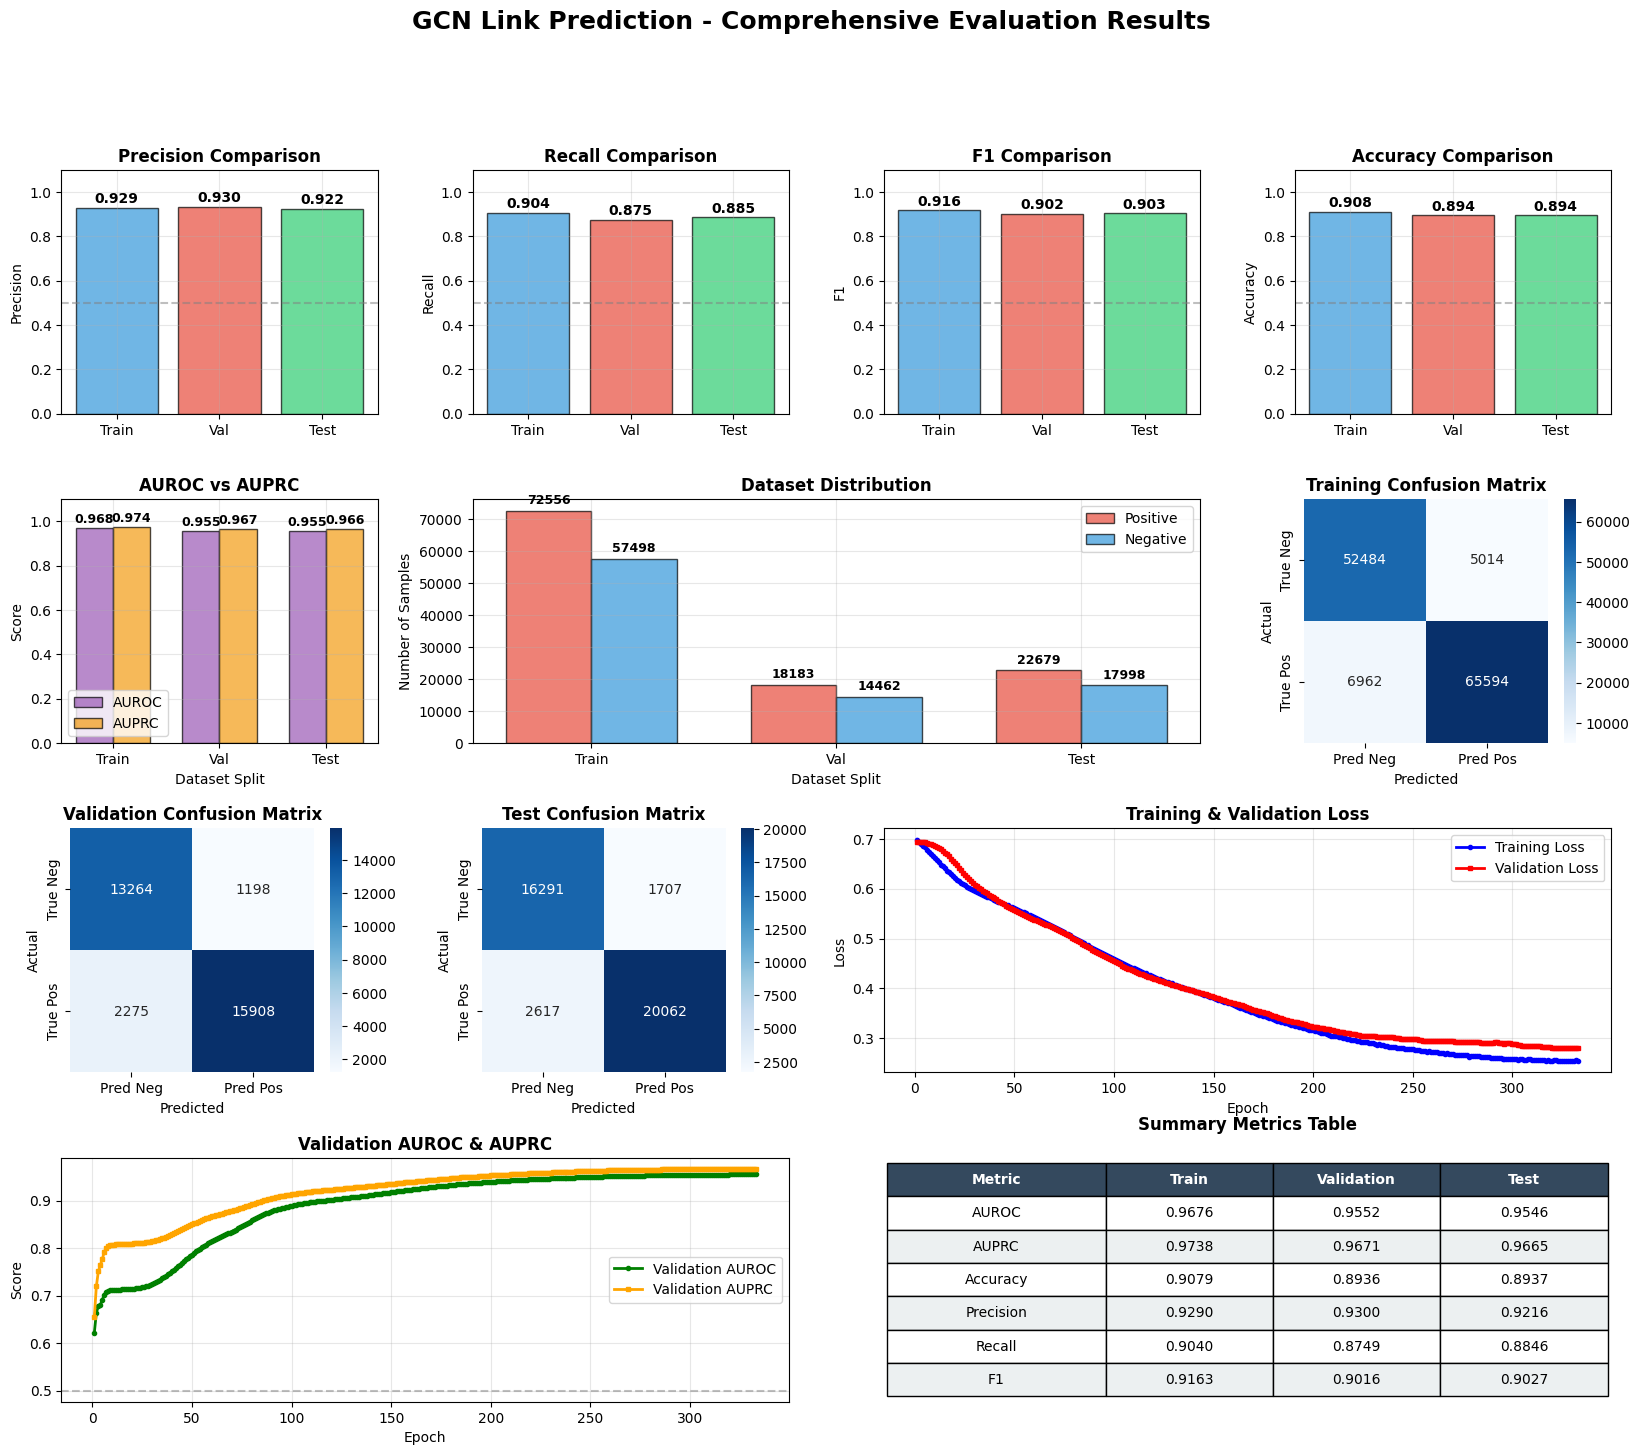

ROC/PR curves saved to: sage_curves.png


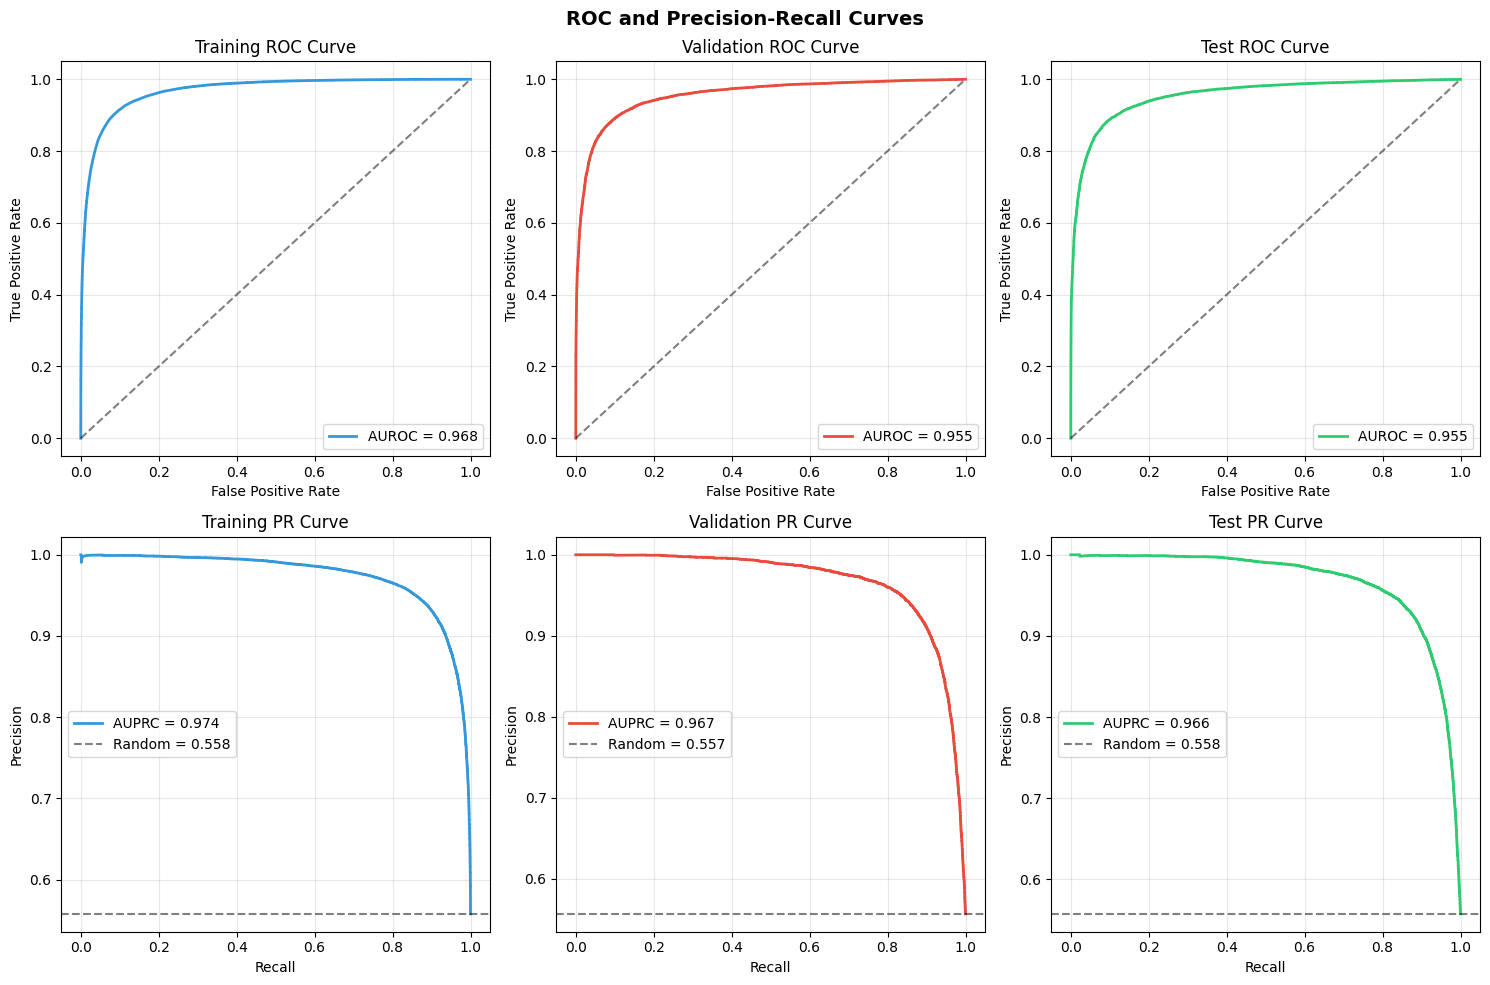

Confusion matrices saved to: sage_matrices.png


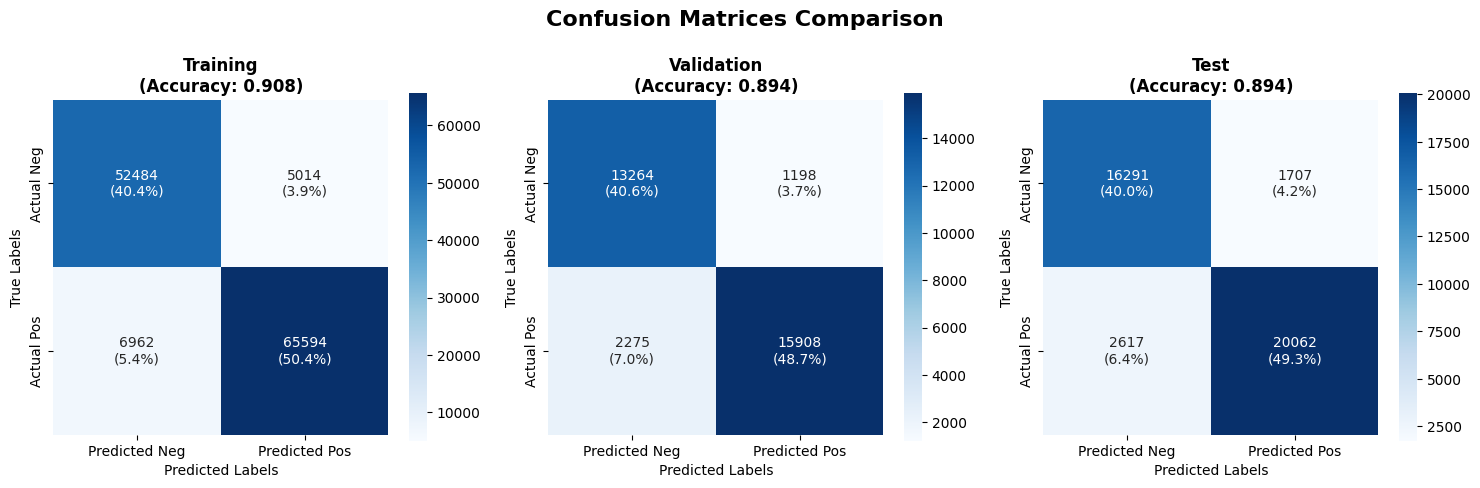

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, SAGEConv  
from torch_geometric.nn import BatchNorm, LayerNorm  
from sklearn.metrics import (
    roc_auc_score, average_precision_score, accuracy_score, 
    precision_recall_fscore_support, confusion_matrix,
    precision_recall_curve, roc_curve
)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec


class GraphSAGELinkPredictor(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels=64, dropout=0.3, aggr='mean'):
        super(GraphSAGELinkPredictor, self).__init__()
        self.dropout = dropout

        self.sage1 = SAGEConv(in_channels, hidden_channels, aggr=aggr)
        self.bn1 = BatchNorm(hidden_channels)
        
        self.sage2 = SAGEConv(hidden_channels, hidden_channels, aggr=aggr)
        self.bn2 = BatchNorm(hidden_channels)
        
        self.sage3 = SAGEConv(hidden_channels, out_channels, aggr=aggr)
        self.bn3 = BatchNorm(out_channels)
        
        self.decoder = nn.Sequential(
            nn.Linear(out_channels * 2, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )
    
    def encode(self, x, edge_index):
        x = self.sage1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        
        x = self.sage2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        
        x = self.sage3(x, edge_index)
        x = self.bn3(x)
        return x
    
    def decode(self, z, edge_label_index):
        z_src = z[edge_label_index[0]]
        z_dst = z[edge_label_index[1]]
        edge_rep = torch.cat([z_src, z_dst], dim=-1)
        return self.decoder(edge_rep).squeeze(-1)
    
    def forward(self, x, edge_index, edge_label_index):
        z = self.encode(x, edge_index)
        return self.decode(z, edge_label_index)

def compute_loss(pred, label):
    return F.binary_cross_entropy_with_logits(pred, label.float())


def find_optimal_threshold(y_true, y_prob):
    """Find optimal threshold using Youden's J statistic"""
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    j_scores = tpr - fpr
    optimal_idx = np.argmax(j_scores)
    return thresholds[optimal_idx]


@torch.no_grad()
def compute_metrics(pred, label, threshold=None):
    """Compute evaluation metrics using sklearn"""
    prob = torch.sigmoid(pred).detach().cpu().numpy()
    label = label.detach().cpu().numpy()
    
    if threshold is None:
        threshold = find_optimal_threshold(label, prob)
    
    pred_binary = (prob >= threshold).astype(int)
    
    auroc = roc_auc_score(label, prob)
    auprc = average_precision_score(label, prob)
    accuracy = accuracy_score(label, pred_binary)

    precision, recall, f1, _ = precision_recall_fscore_support(
        label, pred_binary, average='binary', zero_division=0
    )

    tn, fp, fn, tp = confusion_matrix(label, pred_binary).ravel()

    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    return {
        "AUROC": auroc,
        "AUPRC": auprc,

        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "Specificity": specificity,
        "F1": f1,

        "TP": int(tp),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),

        "Threshold": threshold,
        "Total_Samples": len(label),
        "Positive_Samples": int(np.sum(label)),
        "Negative_Samples": int(len(label) - np.sum(label))
    }


def print_metrics(metrics, dataset_name=""):
    """Print metrics in a clean format"""
    print(f"{dataset_name} METRICS")
    print(f"{'='*50}")
    
    print(f"THRESHOLD-INDEPENDENT:")
    print(f"   AUROC:           {metrics['AUROC']:.4f}")
    print(f"   AUPRC:           {metrics['AUPRC']:.4f}")
    
    print(f"\nCLASSIFICATION (Threshold: {metrics['Threshold']:.4f}):")
    print(f"   Accuracy:        {metrics['Accuracy']:.4f}")
    print(f"   Precision:       {metrics['Precision']:.4f}")
    print(f"   Recall:          {metrics['Recall']:.4f}")
    print(f"   Specificity:     {metrics['Specificity']:.4f}")
    print(f"   F1-Score:        {metrics['F1']:.4f}")
    
    print(f"\nCONFUSION MATRIX:")
    print(f"   True Pos (TP):   {metrics['TP']}")
    print(f"   True Neg (TN):   {metrics['TN']}")
    print(f"   False Pos (FP):  {metrics['FP']}")
    print(f"   False Neg (FN):  {metrics['FN']}")
    
    print(f"\nDATASET INFO:")
    print(f"   Total:           {metrics['Total_Samples']}")
    print(f"   Positive:        {metrics['Positive_Samples']} ({metrics['Positive_Samples']/metrics['Total_Samples']*100:.1f}%)")
    print(f"   Negative:        {metrics['Negative_Samples']} ({metrics['Negative_Samples']/metrics['Total_Samples']*100:.1f}%)")


def train(model, data, optimizer):
    model.train()
    optimizer.zero_grad()
    pred = model(data.x, data.edge_index, data.edge_label_index)
    loss = compute_loss(pred, data.edge_label)
    loss.backward()
    optimizer.step()
    return loss.item()


@torch.no_grad()
def evaluate(model, data, compute_detailed=False):
    model.eval()
    pred = model(data.x, data.edge_index, data.edge_label_index)
    loss = compute_loss(pred, data.edge_label)
    
    if compute_detailed:
        metrics = compute_metrics(pred, data.edge_label)
        return loss.item(), metrics
    else:
        prob = torch.sigmoid(pred).detach().cpu().numpy()
        label = data.edge_label.detach().cpu().numpy()
        quick_metrics = {
            "AUROC": roc_auc_score(label, prob),
            "AUPRC": average_precision_score(label, prob)
        }
        return loss.item(), quick_metrics


def run_training(model, data_train, data_val, data_test, optimizer, 
                max_epochs=400, patience=10):
    """Training loop with comprehensive evaluation"""

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=5, verbose=True
    )

    best_val_auc = 0
    patience_counter = 0
    best_model_state = None

    training_history = {
        'train_loss': [],
        'val_loss': [], 
        'val_auroc': [],
        'val_auprc': []
    }

    
    for epoch in range(1, max_epochs + 1):
        train_loss = train(model, data_train, optimizer)
        val_loss, val_metrics = evaluate(model, data_val, compute_detailed=False)
        val_auc = val_metrics["AUROC"]
        val_auprc = val_metrics["AUPRC"]

        scheduler.step(val_auc)

        training_history['train_loss'].append(train_loss)
        training_history['val_loss'].append(val_loss)
        training_history['val_auroc'].append(val_auc)
        training_history['val_auprc'].append(val_auprc)

        print(f"Epoch {epoch:03d} | Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val AUROC: {val_auc:.4f} | Val AUPRC: {val_auprc:.4f}")

        if val_auc > best_val_auc:
            best_val_auc = val_auc
            patience_counter = 0
            best_model_state = model.state_dict()
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"\n⏹️ Early stopping at epoch {epoch}. Best Val AUROC: {best_val_auc:.4f}")
            break

    print("\nLoading best model for evaluation...")
    model.load_state_dict(best_model_state)

    train_loss, train_metrics = evaluate(model, data_train, compute_detailed=True)
    val_loss, val_metrics = evaluate(model, data_val, compute_detailed=True) 
    test_loss, test_metrics = evaluate(model, data_test, compute_detailed=True)

    print_metrics(train_metrics, "TRAINING")
    print_metrics(val_metrics, "VALIDATION") 
    print_metrics(test_metrics, "TEST")

    print(f"\n{'='*70}")
    print(f"SUMMARY TABLE")
    print(f"{'='*70}")
    print(f"{'Metric':<15} {'Train':<12} {'Validation':<12} {'Test':<12}")
    print(f"{'-'*55}")
    for metric in ['AUROC', 'AUPRC', 'Accuracy', 'Precision', 'Recall', 'F1']:
        print(f"{metric:<15} {train_metrics[metric]:<12.4f} {val_metrics[metric]:<12.4f} {test_metrics[metric]:<12.4f}")
    
    return model, train_metrics, val_metrics, test_metrics, training_history


def plot_results(train_metrics, val_metrics, test_metrics, training_history=None, save_path=None):
    """Create comprehensive plots for evaluation results with proper layout"""
    plt.style.use('default')
    sns.set_palette("husl")
    
    fig = plt.figure(figsize=(20, 16))

    gs = GridSpec(4, 4, figure=fig, hspace=0.35, wspace=0.3)

    colors = ['#3498db', '#e74c3c', '#2ecc71']
    splits = ['Train', 'Val', 'Test']
    split_metrics = [train_metrics, val_metrics, test_metrics]

    metrics_to_plot = ['Precision', 'Recall', 'F1', 'Accuracy']
    
    for i, metric in enumerate(metrics_to_plot):
        ax = fig.add_subplot(gs[0, i])
        values = [split_metric[metric] for split_metric in split_metrics]
        bars = ax.bar(splits, values, color=colors, alpha=0.7, edgecolor='black', linewidth=1)

        for bar, value in zip(bars, values):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                   f'{value:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
        
        ax.set_title(f'{metric} Comparison', fontsize=12, fontweight='bold')
        ax.set_ylabel(metric, fontsize=10)
        ax.set_ylim(0, 1.1)
        ax.grid(True, alpha=0.3)
        ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)

    ax = fig.add_subplot(gs[1, 0])
    auroc_values = [split_data['AUROC'] for split_data in split_metrics]
    auprc_values = [split_data['AUPRC'] for split_data in split_metrics]
    
    x = np.arange(len(splits))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, auroc_values, width, label='AUROC', color='#9b59b6', alpha=0.7, edgecolor='black')
    bars2 = ax.bar(x + width/2, auprc_values, width, label='AUPRC', color='#f39c12', alpha=0.7, edgecolor='black')

    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                   f'{height:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
    
    ax.set_xlabel('Dataset Split')
    ax.set_ylabel('Score')
    ax.set_title('AUROC vs AUPRC', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(splits)
    ax.set_ylim(0, 1.1)
    ax.legend()
    ax.grid(True, alpha=0.3)

    ax = fig.add_subplot(gs[1, 1:3])
    total_samples = [m['Total_Samples'] for m in split_metrics]
    pos_samples = [m['Positive_Samples'] for m in split_metrics]
    neg_samples = [m['Negative_Samples'] for m in split_metrics]
    
    x = np.arange(len(splits))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, pos_samples, width, label='Positive', color='#e74c3c', alpha=0.7, edgecolor='black')
    bars2 = ax.bar(x + width/2, neg_samples, width, label='Negative', color='#3498db', alpha=0.7, edgecolor='black')

    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + max(total_samples)*0.01,
                   f'{int(height)}', ha='center', va='bottom', fontweight='bold', fontsize=9)
    
    ax.set_xlabel('Dataset Split')
    ax.set_ylabel('Number of Samples')
    ax.set_title('Dataset Distribution', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(splits)
    ax.legend()
    ax.grid(True, alpha=0.3)

    cm_positions = [(1, 3), (2, 0), (2, 1)]
    cm_titles = ['Training', 'Validation', 'Test']
    
    for idx, (split_metrics_data, title, pos) in enumerate(zip(split_metrics, cm_titles, cm_positions)):
        ax = fig.add_subplot(gs[pos[0], pos[1]])

        cm_data = np.array([[split_metrics_data['TN'], split_metrics_data['FP']],
                           [split_metrics_data['FN'], split_metrics_data['TP']]])

        sns.heatmap(cm_data, annot=True, fmt='d', cmap='Blues', 
                   xticklabels=['Pred Neg', 'Pred Pos'],
                   yticklabels=['True Neg', 'True Pos'],
                   ax=ax, cbar=True, square=True)
        
        ax.set_title(f'{title} Confusion Matrix', fontweight='bold')
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')

    if training_history is not None:
        ax1 = fig.add_subplot(gs[2, 2:4])
        epochs = range(1, len(training_history['train_loss']) + 1)
        
        ax1.plot(epochs, training_history['train_loss'], 'b-', label='Training Loss', linewidth=2, marker='o', markersize=3)
        ax1.plot(epochs, training_history['val_loss'], 'r-', label='Validation Loss', linewidth=2, marker='s', markersize=3)
        
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Loss')
        ax1.set_title('Training & Validation Loss', fontweight='bold')
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        ax2 = fig.add_subplot(gs[3, 0:2])
        ax2.plot(epochs, training_history['val_auroc'], 'g-', label='Validation AUROC', linewidth=2, marker='o', markersize=3)
        ax2.plot(epochs, training_history['val_auprc'], 'orange', label='Validation AUPRC', linewidth=2, marker='s', markersize=3)
        
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('Score')
        ax2.set_title('Validation AUROC & AUPRC', fontweight='bold')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        ax2.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random (0.5)')

        ax3 = fig.add_subplot(gs[3, 2:4])
        ax3.axis('off')

        table_data = []
        metrics_for_table = ['AUROC', 'AUPRC', 'Accuracy', 'Precision', 'Recall', 'F1']
        
        for metric in metrics_for_table:
            row = [metric, 
                   f"{train_metrics[metric]:.4f}",
                   f"{val_metrics[metric]:.4f}", 
                   f"{test_metrics[metric]:.4f}"]
            table_data.append(row)
        
        table = ax3.table(cellText=table_data,
                         colLabels=['Metric', 'Train', 'Validation', 'Test'],
                         cellLoc='center',
                         loc='center',
                         colWidths=[0.3, 0.23, 0.23, 0.23])
        
        table.auto_set_font_size(False)
        table.set_fontsize(10)
        table.scale(1, 2)

        for i in range(len(metrics_for_table) + 1):
            for j in range(4):
                cell = table[(i, j)]
                if i == 0:  # Header row
                    cell.set_facecolor('#34495e')
                    cell.set_text_props(weight='bold', color='white')
                else:
                    cell.set_facecolor('#ecf0f1' if i % 2 == 0 else 'white')
                    cell.set_text_props(weight='normal')
        
        ax3.set_title('Summary Metrics Table', fontweight='bold', pad=20)
    
    else:
        ax3 = fig.add_subplot(gs[2:4, 2:4])
        ax3.axis('off')

        table_data = []
        all_metrics = ['AUROC', 'AUPRC', 'Accuracy', 'Precision', 'Recall', 'Specificity', 'F1']
        
        for metric in all_metrics:
            row = [metric, 
                   f"{train_metrics[metric]:.4f}",
                   f"{val_metrics[metric]:.4f}", 
                   f"{test_metrics[metric]:.4f}"]
            table_data.append(row)
        
        table = ax3.table(cellText=table_data,
                         colLabels=['Metric', 'Train', 'Validation', 'Test'],
                         cellLoc='center',
                         loc='center',
                         colWidths=[0.3, 0.23, 0.23, 0.23])
        
        table.auto_set_font_size(False)
        table.set_fontsize(11)
        table.scale(1, 1.8)

        for i in range(len(all_metrics) + 1):
            for j in range(4):
                cell = table[(i, j)]
                if i == 0:  
                    cell.set_facecolor('#34495e')
                    cell.set_text_props(weight='bold', color='white')
                else:
                    cell.set_facecolor('#ecf0f1' if i % 2 == 0 else 'white')
                    cell.set_text_props(weight='normal')
        
        ax3.set_title('Comprehensive Metrics Summary', fontweight='bold', pad=20)
    
    fig.suptitle('GCN Link Prediction - Comprehensive Evaluation Results', 
                 fontsize=18, fontweight='bold', y=0.98)

    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"Plot saved to: {save_path}")
    
    plt.show()


def plot_confusion_matrices(train_metrics, val_metrics, test_metrics, save_path=None):
    """Create a dedicated confusion matrix visualization"""
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle('Confusion Matrices Comparison', fontsize=16, fontweight='bold')
    
    split_metrics = [train_metrics, val_metrics, test_metrics]
    titles = ['Training', 'Validation', 'Test']
    
    for idx, (metrics, title, ax) in enumerate(zip(split_metrics, titles, axes)):
        cm_data = np.array([[metrics['TN'], metrics['FP']],
                           [metrics['FN'], metrics['TP']]])

        cm_percent = cm_data / cm_data.sum() * 100

        annotations = np.array([[f"{cm_data[i,j]}\n({cm_percent[i,j]:.1f}%)" 
                               for j in range(2)] for i in range(2)])

        sns.heatmap(cm_data, annot=annotations, fmt='', cmap='Blues', 
                   xticklabels=['Predicted Neg', 'Predicted Pos'],
                   yticklabels=['Actual Neg', 'Actual Pos'],
                   ax=ax, cbar=True, square=True, cbar_kws={'shrink': 0.8})
        
        ax.set_title(f'{title}\n(Accuracy: {metrics["Accuracy"]:.3f})', fontweight='bold')
        ax.set_xlabel('Predicted Labels')
        ax.set_ylabel('True Labels')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"Confusion matrices saved to: {save_path}")
    
    plt.show()

def plot_roc_pr_curves(model, data_train, data_val, data_test, save_path=None):
    """Plot ROC and Precision-Recall curves"""
    model.eval()
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle('ROC and Precision-Recall Curves', fontsize=14, fontweight='bold')
    
    datasets = [
        (data_train, 'Training', '#3498db'),
        (data_val, 'Validation', '#e74c3c'), 
        (data_test, 'Test', '#2ecc71')
    ]
    
    for i, (data, name, color) in enumerate(datasets):
        with torch.no_grad():
            pred = model(data.x, data.edge_index, data.edge_label_index)
            prob = torch.sigmoid(pred).cpu().numpy()
            label = data.edge_label.cpu().numpy()

        fpr, tpr, _ = roc_curve(label, prob)
        auroc = roc_auc_score(label, prob)
        
        axes[0, i].plot(fpr, tpr, color=color, linewidth=2, label=f'AUROC = {auroc:.3f}')
        axes[0, i].plot([0, 1], [0, 1], 'k--', alpha=0.5)
        axes[0, i].set_xlabel('False Positive Rate')
        axes[0, i].set_ylabel('True Positive Rate')
        axes[0, i].set_title(f'{name} ROC Curve')
        axes[0, i].legend()
        axes[0, i].grid(True, alpha=0.3)

        precision, recall, _ = precision_recall_curve(label, prob)
        auprc = average_precision_score(label, prob)
        
        axes[1, i].plot(recall, precision, color=color, linewidth=2, label=f'AUPRC = {auprc:.3f}')
        axes[1, i].axhline(y=np.mean(label), color='k', linestyle='--', alpha=0.5,
                          label=f'Random = {np.mean(label):.3f}')
        axes[1, i].set_xlabel('Recall')
        axes[1, i].set_ylabel('Precision')
        axes[1, i].set_title(f'{name} PR Curve')
        axes[1, i].legend()
        axes[1, i].grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"ROC/PR curves saved to: {save_path}")
    
    plt.show()


if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = GraphSAGELinkPredictor(
    in_channels=64,
    hidden_channels=256,
    out_channels=64,
    dropout=0.3, 
    aggr='mean'
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=5e-4)

    data_train = train_data.to(device)
    data_val = val_data.to(device)
    data_test = test_data.to(device)

    trained_model, train_results, val_results, test_results, history = run_training(
        model, data_train, data_val, data_test, optimizer,
        max_epochs=400, patience=10
    )

    plot_results(train_results, val_results, test_results, 
                training_history=history, save_path="sage_results.png")
    plot_roc_pr_curves(trained_model, data_train, data_val, data_test, 
                      save_path="sage_curves.png")
    plot_confusion_matrices(train_results, val_results, test_results, save_path="sage_matrices.png")

## === EXPLAINABILITY ===

In [46]:
# === Cell 1: Setup για explainability ===

import os
import pickle
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from sklearn.metrics import roc_auc_score

device = next(trained_model.parameters()).device
idx_to_protein = {v: k for k, v in protein_to_idx.items()}

if 'go_name_space_dict' not in globals():
    with open(go_name_space_dict_pth, 'rb') as fp:
        go_name_space_dict = pickle.load(fp)

if 'go_id_dict' not in globals():
    with open(go_id_dict_pth, 'rb') as fp:
        go_id_dict = pickle.load(fp)

if 'go_emb_dict' not in globals():
    go_emb_dict = {}
    with open(go_embed_pth, 'r') as f:
        next(f)
        for line in f:
            parts = line.strip().split()
            go_emb_dict[int(parts[0])] = np.asarray(parts[1:], dtype=np.float32)


def protein_namespace_breakdown(protein_idx, protein_go_anno, go_name_space_dict):
    counts = defaultdict(int)
    for t in protein_go_anno.get(idx_to_protein[protein_idx], []):
        counts[go_name_space_dict.get(t, 'unknown')] += 1
    return dict(counts)

=== Attention Case Study: 4932.YBR160W (idx=332) ===

--- Layer 1 top-10 attended neighbors ---
   1. 4932.YML119W               α=0.0057   GO: [ce=1]
   2. 4932.YDL230W               α=0.0057   GO: [mo=1, bi=3, ce=2]
   3. 4932.YLL002W               α=0.0056   GO: [mo=2, bi=9, ce=1]
   4. 4932.YNL197C               α=0.0056   GO: [mo=1, bi=7, ce=3]
   5. 4932.YGL003C               α=0.0056   GO: [mo=3, bi=9, ce=3]
   6. 4932.YGR040W               α=0.0056   GO: [mo=3, bi=9, ce=3]
   7. 4932.YBL084C               α=0.0056   GO: [mo=1, bi=5, ce=3]
   8. 4932.YGL116W               α=0.0056   GO: [mo=2, bi=6, ce=5]
   9. 4932.YOR127W               α=0.0056   GO: [mo=1, bi=11, ce=5]
  10. 4932.YOR208W               α=0.0056   GO: [bi=5, mo=1, ce=1]

--- Layer 2 top-10 attended neighbors ---
   1. 4932.YDL230W               α=0.0107   GO: [mo=1, bi=3, ce=2]
   2. 4932.YLR167W               α=0.0103   GO: [mo=3, bi=6, ce=3]
   3. 4932.YKR094C               α=0.0100   GO: [mo=3, bi=6, ce=4]
 

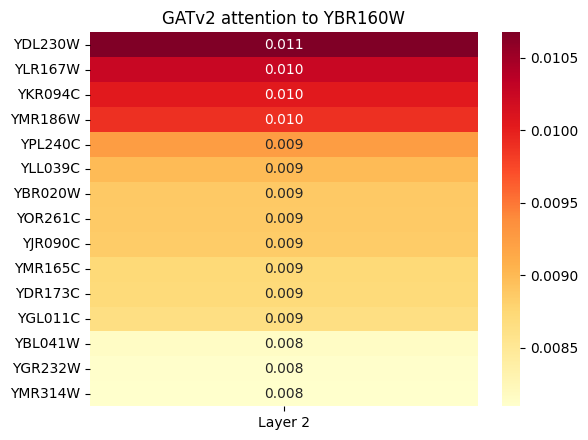

In [ ]:
# === Cell 2: GAT Attention Extraction & Case Study ===

@torch.no_grad()
def extract_gat_attention(model, data):
    """Επιστρέφει τα attention weights των 2 GATv2 layers ως [(edge_index, alpha), ...]."""
    model.eval()
    x, edge_index = data.x.to(device), data.edge_index.to(device)
    x1, (ei1, alpha1) = model.gat1(x, edge_index, return_attention_weights=True)
    x1 = F.relu(model.bn1(x1))
    _,  (ei2, alpha2) = model.gat2(x1, edge_index, return_attention_weights=True)
    return [(ei1.cpu(), alpha1.cpu()), (ei2.cpu(), alpha2.cpu())]


def top_attended_neighbors(attns, target_idx, layer=1, k=10, head_aggregation='mean'):
    """Top-k γείτονες ενός protein με βάση τα attention weights."""
    edge_index, alpha = attns[layer]
    if alpha.dim() == 2 and alpha.size(1) > 1:
        alpha_agg = alpha.mean(dim=1) if head_aggregation == 'mean' else alpha.max(dim=1).values
    else:
        alpha_agg = alpha.squeeze()

    mask = edge_index[1] == target_idx
    neighbors, weights = edge_index[0][mask], alpha_agg[mask]
    if len(weights) == 0:
        return [], []
    topk = torch.topk(weights, k=min(k, len(weights)))
    return neighbors[topk.indices].tolist(), topk.values.tolist()


def attention_case_study(model, data, target_protein, prot2idx, idx2prot,
                         prot2go, go_namespace_dict, k=10):
    """Case study για ένα target protein: tabular output με top-k γείτονες ανά layer."""
    if target_protein not in prot2idx:
        print(f'{target_protein} not found in graph.')
        return None
    tgt_idx = prot2idx[target_protein]
    attns = extract_gat_attention(model, data)
    print(f'=== Attention Case Study: {target_protein} (idx={tgt_idx}) ===\n')

    for layer in [0, 1]:
        nbrs, weights = top_attended_neighbors(attns, tgt_idx, layer=layer, k=k)
        print(f'--- Layer {layer+1} top-{len(nbrs)} attended neighbors ---')
        for rank, (n, w) in enumerate(zip(nbrs, weights), 1):
            ns = protein_namespace_breakdown(n, prot2go, go_namespace_dict)
            ns_str = ', '.join(f'{k_[:2]}={v}' for k_, v in ns.items())
            print(f'  {rank:2d}. {idx2prot[n]:25s}  α={w:.4f}   GO: [{ns_str}]')
        print()
    return attns


def plot_attention_heatmap(attns, target_idx, idx2prot, layer=1, k=15, save_path=None):
    """Heatmap των top-k attention weights για ένα protein."""
    nbrs, weights = top_attended_neighbors(attns, target_idx, layer=layer, k=k)
    if not nbrs:
        return
    fig, ax = plt.subplots(figsize=(6, max(4, k * 0.3)))
    labels = [idx2prot[n].split('.')[-1][:20] for n in nbrs]
    sns.heatmap(np.array(weights).reshape(-1, 1), annot=True, fmt='.3f',
                yticklabels=labels, xticklabels=[f'Layer {layer+1}'], cmap='YlOrRd', ax=ax)
    ax.set_title(f'GATv2 attention to {idx2prot[target_idx].split(".")[-1]}')
    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path) or '.', exist_ok=True)
        plt.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()


# --- Example usage: CDC28 (yeast) ---
target = '4932.YBR160W'
attns = attention_case_study(trained_model, train_data, target,
                             protein_to_idx, idx_to_protein,
                             protein_go_anno, go_name_space_dict, k=10)
plot_attention_heatmap(attns, protein_to_idx[target], idx_to_protein,
                       layer=1, k=15, save_path='figures/cdc28_attention.png')

In [48]:
# === Cell 3: GNNExplainer for Link Prediction ===

from torch_geometric.explain import Explainer, GNNExplainer
from torch_geometric.explain.config import ModelConfig


class LinkPredWrapper(nn.Module):
    """Wrapper που γυρνάει logits ανά candidate edge για το PyG Explainer (task_level='edge')."""
    def __init__(self, gnn_model, edge_label_index):
        super().__init__()
        self.gnn = gnn_model
        self.register_buffer('edge_label_index', edge_label_index)

    def forward(self, x, edge_index):
        z = self.gnn.encode(x, edge_index)
        src, dst = self.edge_label_index[0], self.edge_label_index[1]
        h = torch.cat([z[src], z[dst]], dim=-1)
        return self.gnn.decoder(h).view(-1)


def explain_pair(model, data, src_idx, dst_idx, epochs=200, lr=0.01, top_k_edges=10):
    """GNNExplainer για ένα ζευγάρι. Επιστρέφει (explanation, dict με top edges & feature dims)."""
    edge_label_index = torch.tensor([[src_idx], [dst_idx]], device=device)
    wrapped = LinkPredWrapper(model, edge_label_index).to(device).eval()

    explainer = Explainer(
        model=wrapped,
        algorithm=GNNExplainer(epochs=epochs, lr=lr),
        explanation_type='model',
        model_config=ModelConfig(mode='binary_classification', task_level='edge', return_type='raw'),
        node_mask_type='attributes',
        edge_mask_type='object',
    )
    explanation = explainer(x=data.x.to(device), edge_index=data.edge_index.to(device))

    edge_mask = explanation.edge_mask.detach().cpu()
    top_edges_idx = torch.topk(edge_mask, k=min(top_k_edges, len(edge_mask))).indices
    top_edges = [
        {'src': data.edge_index[0, ei].item(),
         'dst': data.edge_index[1, ei].item(),
         'importance': edge_mask[ei].item()}
        for ei in top_edges_idx
    ]

    node_mask = explanation.node_mask.detach().cpu()
    pair_mask = (node_mask[src_idx] + node_mask[dst_idx]) / 2.0
    top_dims = torch.topk(pair_mask, k=10).indices.tolist()

    return explanation, {
        'top_edges': top_edges,
        'top_feature_dims': top_dims,
        'edge_mask': edge_mask,
        'node_mask': node_mask,
    }


def fidelity_metrics(explainer, explanation):
    """Fidelity+/- από το PyG."""
    from torch_geometric.explain.metric import fidelity
    return fidelity(explainer, explanation)


# --- Example usage: CDC28 ↔ YDL230W ---
src_idx = protein_to_idx['4932.YBR160W']
dst_idx = protein_to_idx['4932.YDL230W']
explanation, result = explain_pair(trained_model, train_data, src_idx, dst_idx)

print(f'Top {len(result["top_edges"])} important edges for ({idx_to_protein[src_idx]}, {idx_to_protein[dst_idx]}):')
for e in result['top_edges']:
    print(f"  ({idx_to_protein[e['src']]}, {idx_to_protein[e['dst']]})  importance={e['importance']:.4f}")
print(f'Top feature dimensions: {result["top_feature_dims"]}')

Top 10 important edges for (4932.YBR160W, 4932.YDL230W):
  (4932.YML119W, 4932.YBR160W)  importance=0.3920
  (4932.YDL024C, 4932.YPR073C)  importance=0.2884
  (4932.YNL042W, 4932.YBR160W)  importance=0.2469
  (4932.YER032W, 4932.YBR160W)  importance=0.2385
  (4932.YKR077W, 4932.YBR160W)  importance=0.2284
  (4932.YDR451C, 4932.YBR160W)  importance=0.2192
  (4932.YLR133W, 4932.YBR160W)  importance=0.2172
  (4932.YLR187W, 4932.YBR160W)  importance=0.2169
  (4932.YOR066W, 4932.YBR160W)  importance=0.2166
  (4932.YNL197C, 4932.YBR160W)  importance=0.2156
Top feature dimensions: [22, 35, 52, 27, 18, 21, 37, 60, 48, 20]


In [ ]:
# === Cell 4: Integrated Gradients with GO Term Mapping ===

from captum.attr import IntegratedGradients


class PairScoreModel(nn.Module):
    """IG wrapper: γυρνάει P(interaction) για fixed (src, dst). Δέχεται x_batched [B, N, F] -> [B]."""
    def __init__(self, gnn_model, edge_index, src, dst):
        super().__init__()
        self.gnn = gnn_model
        self.register_buffer('edge_index', edge_index)
        self.src, self.dst = src, dst

    def forward(self, x_batched):
        outputs = []
        for b in range(x_batched.shape[0]):
            z = self.gnn.encode(x_batched[b], self.edge_index)
            h = torch.cat([z[self.src], z[self.dst]], dim=-1).unsqueeze(0)
            logit = self.gnn.decoder(h).view(-1)
            outputs.append(torch.sigmoid(logit).squeeze())
        return torch.stack(outputs)


def integrated_gradients_pair(model, data, src_idx, dst_idx, n_steps=50):
    """IG attributions για ένα ζευγάρι. Returns [N, 64]."""
    scorer = PairScoreModel(model, data.edge_index.to(device), src_idx, dst_idx).to(device).eval()
    ig = IntegratedGradients(scorer)
    x = data.x.to(device).clone().detach().unsqueeze(0)
    baseline = torch.zeros_like(x)
    attributions = ig.attribute(inputs=x, baselines=baseline,
                                n_steps=n_steps, internal_batch_size=1)
    return attributions.squeeze(0).detach().cpu()


def map_attribution_to_go_terms(attribution_vector, protein_id, protein_go_anno,
                                go_emb_dict, go_id_dict, go_name_space_dict, top_k=10):
    """Από attribution διανύσματος [64] -> top-k GO terms του protein με βάση τη συνεισφορά τους."""
    terms = protein_go_anno.get(protein_id, [])
    if not terms:
        return []
    n = len(terms)
    attr = np.asarray(attribution_vector)
    scores = []
    for t in terms:
        int_id = go_id_dict.get(t)
        if int_id is None or int_id not in go_emb_dict:
            continue
        s = float(np.dot(attr, np.asarray(go_emb_dict[int_id]))) / n
        scores.append((t, s, go_name_space_dict.get(t, 'unknown')))
    scores.sort(key=lambda x: abs(x[1]), reverse=True)
    return scores[:top_k]


def explain_pair_with_ig(model, data, src_idx, dst_idx,
                         protein_go_anno, go_emb_dict, go_id_dict, go_name_space_dict,
                         idx_to_protein, top_k=10, n_steps=50):
    """Single-pair IG case study με GO term mapping."""
    print(f'=== IG explanation: {idx_to_protein[src_idx]} ↔ {idx_to_protein[dst_idx]} ===\n')
    attributions = integrated_gradients_pair(model, data, src_idx, dst_idx, n_steps=n_steps)

    for endpoint, label in [(src_idx, 'SOURCE'), (dst_idx, 'TARGET')]:
        print(f'--- {label}: {idx_to_protein[endpoint]} ---')
        top_terms = map_attribution_to_go_terms(
            attributions[endpoint].numpy(), idx_to_protein[endpoint],
            protein_go_anno, go_emb_dict, go_id_dict, go_name_space_dict, top_k=top_k,
        )
        for rank, (term, score, ns) in enumerate(top_terms, 1):
            print(f'  {rank:2d}. {term}  ({ns[:2]})  importance={score:+.4f}')
        print()
    return attributions


def aggregate_namespace_importance(model, data, test_pairs,
                                   protein_go_anno, go_emb_dict, go_id_dict, go_name_space_dict,
                                   idx_to_protein, n_samples=200, n_steps=20):
    """Aggregate IG πάνω σε n_samples test pairs -> breakdown |importance| ανά GO namespace."""
    namespace_mass = defaultdict(float)
    n_pairs = min(n_samples, len(test_pairs))

    for i, (src, dst) in enumerate(test_pairs[:n_pairs]):
        if i % 20 == 0:
            print(f'  Processing pair {i}/{n_pairs}...')
        attributions = integrated_gradients_pair(model, data, src, dst, n_steps=n_steps)
        for endpoint in (src, dst):
            for term, score, ns in map_attribution_to_go_terms(
                attributions[endpoint].numpy(), idx_to_protein[endpoint],
                protein_go_anno, go_emb_dict, go_id_dict, go_name_space_dict, top_k=20,
            ):
                namespace_mass[ns] += abs(score)

    total = sum(namespace_mass.values())
    print('\nNamespace importance breakdown:')
    for ns, m in sorted(namespace_mass.items(), key=lambda x: -x[1]):
        print(f'  {ns:25s}: {100*m/total:5.1f}%')
    return namespace_mass


# --- Example usage: CDC28 ↔ YDL230W ---
src = protein_to_idx['4932.YBR160W']
dst = protein_to_idx['4932.YDL230W']

attrs = explain_pair_with_ig(
    trained_model, train_data, src, dst,
    protein_go_anno, go_emb_dict, go_id_dict, go_name_space_dict,
    idx_to_protein, top_k=10, n_steps=50,
)

test_pairs = list(zip(test_data.edge_label_index[0].tolist(),
                      test_data.edge_label_index[1].tolist()))

ns_mass = aggregate_namespace_importance(
    trained_model, train_data, test_pairs,
    protein_go_anno, go_emb_dict, go_id_dict, go_name_space_dict,
    idx_to_protein, n_samples=200, n_steps=30,
)

=== IG explanation: 4932.YBR160W ↔ 4932.YDL230W ===

--- SOURCE: 4932.YBR160W ---
   1. GO:0045944  (bi)  importance=+0.0003
   2. GO:0070816  (bi)  importance=+0.0003
   3. GO:0010569  (bi)  importance=+0.0003
   4. GO:0010389  (bi)  importance=+0.0003
   5. GO:0045875  (bi)  importance=+0.0003
   6. GO:2001033  (bi)  importance=+0.0002
   7. GO:0006370  (bi)  importance=+0.0002
   8. GO:1902596  (bi)  importance=+0.0002
   9. GO:0090169  (bi)  importance=+0.0002
  10. GO:0010494  (ce)  importance=+0.0002

--- TARGET: 4932.YDL230W ---
   1. GO:0001403  (bi)  importance=+0.0046
   2. GO:0007124  (bi)  importance=+0.0044
   3. GO:0004725  (mo)  importance=+0.0030
   4. GO:0005737  (ce)  importance=+0.0027
   5. GO:0005739  (ce)  importance=+0.0022
   6. GO:0006470  (bi)  importance=+0.0011

  Processing pair 0/200...
  Processing pair 20/200...
  Processing pair 40/200...
  Processing pair 60/200...
  Processing pair 80/200...
  Processing pair 100/200...
  Processing pair 120/200...
  

In [50]:
# === Cell 5: GO-mean only Baseline (no message passing) ===
# Ποσοτικοποιεί τη συνεισφορά της τοπολογίας πάνω από το static GO-mean input.

from sklearn.metrics import average_precision_score, accuracy_score, f1_score


class GOMeanOnlyMLP(nn.Module):
    """Ίδιος decoder με τα GNN μοντέλα αλλά χωρίς message passing — predicts απευθείας από [x_p, x_q]."""
    def __init__(self, in_channels=64, dropout=0.2):
        super().__init__()
        self.decoder = nn.Sequential(
            nn.Linear(in_channels * 2, 128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, 64),              nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def encode(self, x, edge_index):
        return x  # no-op

    def decode(self, z, src, dst):
        return self.decoder(torch.cat([z[src], z[dst]], dim=-1)).squeeze(-1)

    def forward(self, x, edge_index, edge_label_index):
        return self.decode(self.encode(x, edge_index), edge_label_index[0], edge_label_index[1])


def train_gomean_baseline(data,
                          train_edge_label_index, train_labels,
                          val_edge_label_index,   val_labels,
                          test_edge_label_index,  test_labels,
                          epochs=400, lr=1e-3, weight_decay=1e-5, dropout=0.2, patience=10):
    """Εκπαιδεύει το GOMeanOnlyMLP με early stopping στο val AUROC."""
    model = GOMeanOnlyMLP(in_channels=data.x.size(1), dropout=dropout).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    bce = nn.BCEWithLogitsLoss()

    x, ei  = data.x.to(device), data.edge_index.to(device)
    tr_idx, tr_y = train_edge_label_index.to(device), train_labels.to(device).float()
    va_idx, va_y = val_edge_label_index.to(device),   val_labels.cpu().numpy()
    te_idx, te_y = test_edge_label_index.to(device),  test_labels.cpu().numpy()

    best_val, no_improve, best_state = 0.0, 0, None
    for epoch in range(1, epochs + 1):
        model.train()
        opt.zero_grad()
        loss = bce(model(x, ei, tr_idx), tr_y)
        loss.backward(); opt.step()

        model.eval()
        with torch.no_grad():
            val_auc = roc_auc_score(va_y, model(x, ei, va_idx).cpu().numpy())
        if val_auc > best_val:
            best_val = val_auc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'Early stop at epoch {epoch}')
                break
        if epoch % 10 == 0:
            print(f'Epoch {epoch:3d} | loss={loss.item():.4f} | val AUROC={val_auc:.4f}')

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        test_logits = model(x, ei, te_idx).cpu().numpy()

    metrics = {
        'auroc': roc_auc_score(te_y, test_logits),
        'auprc': average_precision_score(te_y, test_logits),
        'acc':   accuracy_score(te_y, (test_logits > 0).astype(int)),
        'f1':    f1_score(te_y, (test_logits > 0).astype(int)),
    }
    print(f'\nGO-mean MLP baseline: AUROC={metrics["auroc"]:.4f}  '
          f'AUPRC={metrics["auprc"]:.4f}  Acc={metrics["acc"]:.4f}  F1={metrics["f1"]:.4f}')
    return model, metrics


# --- Example usage ---
baseline_model, baseline_metrics = train_gomean_baseline(
    train_data,
    train_data.edge_label_index, train_data.edge_label,
    val_data.edge_label_index,   val_data.edge_label,
    test_data.edge_label_index,  test_data.edge_label,
)

Epoch  10 | loss=0.6533 | val AUROC=0.7136
Epoch  20 | loss=0.6035 | val AUROC=0.7201
Epoch  30 | loss=0.5850 | val AUROC=0.7385
Epoch  40 | loss=0.5647 | val AUROC=0.7636
Epoch  50 | loss=0.5412 | val AUROC=0.7957
Epoch  60 | loss=0.5097 | val AUROC=0.8311
Epoch  70 | loss=0.4744 | val AUROC=0.8615
Epoch  80 | loss=0.4467 | val AUROC=0.8789
Epoch  90 | loss=0.4293 | val AUROC=0.8893
Epoch 100 | loss=0.4149 | val AUROC=0.8973
Epoch 110 | loss=0.4027 | val AUROC=0.9036
Epoch 120 | loss=0.3926 | val AUROC=0.9086
Epoch 130 | loss=0.3841 | val AUROC=0.9128
Epoch 140 | loss=0.3764 | val AUROC=0.9165
Epoch 150 | loss=0.3693 | val AUROC=0.9196
Epoch 160 | loss=0.3622 | val AUROC=0.9226
Epoch 170 | loss=0.3571 | val AUROC=0.9245
Epoch 180 | loss=0.3523 | val AUROC=0.9263
Epoch 190 | loss=0.3484 | val AUROC=0.9276
Epoch 200 | loss=0.3442 | val AUROC=0.9291
Epoch 210 | loss=0.3405 | val AUROC=0.9303
Epoch 220 | loss=0.3374 | val AUROC=0.9314
Epoch 230 | loss=0.3341 | val AUROC=0.9323
Epoch 240 |

Pairs with input cosine > 0.95: 3/2000
  Output cosine: mean=0.809  std=0.263  range=[0.437, 0.999]


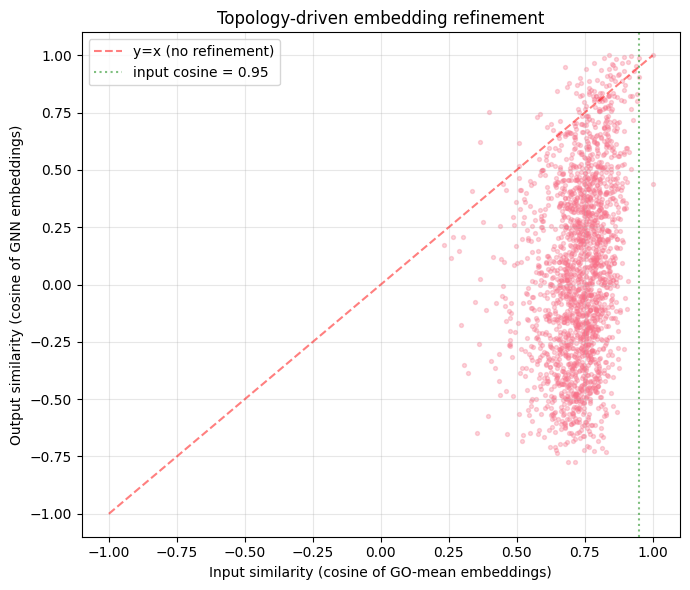

In [51]:
# === Cell 6: Similarity Gap Analysis ===
# Ζευγάρια με παρόμοιο input embedding έχουν διαφορετικό output embedding -> topology-driven refinement.

@torch.no_grad()
def similarity_gap_analysis(model, data, n_pairs=2000, save_path=None):
    model.eval()
    x, ei = data.x.to(device), data.edge_index.to(device)
    z = model.encode(x, ei)

    # Random pairs (drop self-pairs)
    N = data.x.size(0)
    src = torch.randint(0, N, (n_pairs,))
    dst = torch.randint(0, N, (n_pairs,))
    mask = src != dst
    src_dev, dst_dev = src[mask].to(device), dst[mask].to(device)

    sim_input  = F.cosine_similarity(x[src_dev], x[dst_dev], dim=1).cpu().numpy()
    sim_output = F.cosine_similarity(z[src_dev], z[dst_dev], dim=1).cpu().numpy()

    high = sim_input > 0.95
    print(f'Pairs with input cosine > 0.95: {high.sum()}/{len(sim_input)}')
    if high.sum() > 0:
        print(f'  Output cosine: mean={sim_output[high].mean():.3f}  '
              f'std={sim_output[high].std():.3f}  '
              f'range=[{sim_output[high].min():.3f}, {sim_output[high].max():.3f}]')

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.scatter(sim_input, sim_output, alpha=0.3, s=8)
    ax.plot([-1, 1], [-1, 1], 'r--', alpha=0.5, label='y=x (no refinement)')
    ax.axvline(0.95, color='green', linestyle=':', alpha=0.5, label='input cosine = 0.95')
    ax.set_xlabel('Input similarity (cosine of GO-mean embeddings)')
    ax.set_ylabel('Output similarity (cosine of GNN embeddings)')
    ax.set_title('Topology-driven embedding refinement')
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path) or '.', exist_ok=True)
        plt.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()
    return sim_input, sim_output


# --- Example usage ---
si, so = similarity_gap_analysis(trained_model, train_data, n_pairs=2000,
                                 save_path='figures/similarity_gap.png')